# Practical LLMs at Work: Local Models & Prompt Engineering

**Audience:** Beginners who want to use Large Language Models (LLMs) to boost productivity in office work, after-sales service (A/S), mechanical engineering, design, shipbuilding, and maritime operations.

**What this notebook covers**

- Many **realistic workplace scenarios** and example prompts
- **Prompt engineering** techniques you can reuse immediately

- **Calling a local LLM** via **`llama-cpp-python`** (default) with a **GGUF** file from **Hugging Face** — plus optional backends (`ollama`, `transformers`, OpenAI-compatible HTTP)
- A short, practical look at **cloud LLMs** (how they fit in, with illustrative patterns)
- **Step-by-step** code cells—run them top to bottom

> **Tip:** If no local model is running, `call_llm` falls back to **demo mode** so you can still practice prompting.



## How to use this notebook

1. **Run cells in order** (Shift+Enter).
2. Read the markdown above each code cell before running it.
3. Run **Step 0** to install **`llama-cpp-python`** + **`huggingface_hub`**, then **Step 0b** to download a **GGUF** (default: TinyLlama Q4 from the Hub). The notebook defaults to **`LLM_BACKEND=llama_cpp`**. Optional: `LLM_BACKEND=ollama` (needs Ollama + `ollama pull`), `transformers`, or `openai_compatible`.
4. For **cloud** examples, you only need an API key if you choose to run those cells; otherwise read them as reference.

---

## Table of contents

0. **llama-cpp-python** + **GGUF from Hugging Face** (default path)  
1. Environment setup  
2. Workplace use cases (menu of applications)  
3. Prompt engineering fundamentals  
4. Local LLM helper — **`llama-cpp-python` + GGUF** (default) or optional Ollama / transformers / HTTP + connectivity test  
4c. **Hands-on:** detailed code for **every** menu scenario (Office, A/S, Mechanical, Maritime)  
5. **Prompt patterns** — markdown + runnable demos (role, few-shot, steps, JSON, rubric)  
6. **Quick practice** — combine one pattern + your snippet (guided code)  
7. **Mini exercises** — A–D with sample inputs (shorten, translate, UNKNOWN, risk table)  
8. **Cloud LLM** — Mermaid flow + bar chart (no key) + optional OpenAI-compatible API call  
9. **Local vs cloud** — decision guide + weighted scoring code  
10. **Limitations & safety** — markdown + printable checklist + optional LLM critique  

> **Hands-on path:** After Step **4c**, run **Step 5** (patterns) → **Step 6–7** (practice + exercises) → **Step 8** (visual cloud comparison).


## Step 0 — Choose a local LLM backend

This workshop supports **two** ways to run a model **locally**. Pick **one path** below — Step 4 (`call_llm`) will use whichever backend you choose.

| Path | `LLM_BACKEND` | Best for | Setup cells |
|------|---------------|----------|-------------|
| **A — In-notebook GGUF** *(default)* | `llama_cpp` | Self-contained: load a `.gguf` directly with `llama-cpp-python`, no extra service. | Step **0A-1** (install) + Step **0A-2** (download GGUF). |
| **B — Ollama service** | `ollama` | You already use [Ollama](https://ollama.com) or want a persistent local model server with multiple models pulled. The notebook delegates the call to `ollama_model_runner.py` (a tiny terminal helper) — same pattern as **Module 4**. | Step **0B-1** (verify runner) + Step **0B-2** (install Ollama outside the notebook) + Step **0B-3** (smoke test). |

> The **chooser cell** right below sets the `LLM_BACKEND` environment variable for the rest of the notebook. Only run the cells for the path you picked — you can ignore the other path's cells.

### Path A — what you install (PyPI)

- **`llama-cpp-python`** — loads GGUF and runs the model.
- **`huggingface_hub`** — `hf_hub_download` to fetch a **single** `.gguf` from a repo.

By default Path A downloads **TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF** — **`Q4_K_M`** (smaller, good for CPU / Colab). Override the defaults with environment variables **before** running Step 0A-2:

- **`HF_GGUF_REPO`** — e.g. `bartowski/Llama-3.2-3B-Instruct-GGUF`
- **`HF_GGUF_FILE`** — exact filename in that repo (e.g. `Llama-3.2-3B-Instruct-Q4_K_M.gguf`)
- **`HF_TOKEN`** — only if the repo is **gated** (accept terms on the Hub first)

Alternatively, set **`LLAMA_CPP_GGUF`** to a **local** path to any `.gguf` file and skip the Hub download.

If `pip` tries to compile from source and fails, install a C++ toolchain (e.g. **Visual Studio Build Tools** on Windows) or follow the official [llama-cpp-python installation guide](https://github.com/abetlen/llama-cpp-python#installation) for prebuilt wheels (CPU / CUDA / Metal).

### Path B — what you install (Ollama)

- The **Ollama app** (one-time install from <https://ollama.com>) running as a background service.
- One or more models pulled via `ollama pull` (e.g. `llama3.1:8b`, `mistral:7b`, `phi3`).
- The Python library **`requests`** inside the notebook — that is the only extra Python dependency for this path.

Path B uses `ollama_model_runner.py` (in this folder) to send a prompt file to the Ollama HTTP API and print a JSON result, exactly like the Module 4 RAG notebook. The runner accepts one or many models in one call (e.g. `--models llama3.1:8b,mistral:7b`), which makes it easy to compare answers.


In [1]:
# Step 0 — Pick the backend used by Step 4 (`call_llm`)
# Set LLM_BACKEND_CHOICE to one of: "llama_cpp" (default) or "ollama".
import os

LLM_BACKEND_CHOICE = "llama_cpp"  # change to "ollama" to use the Ollama service path

assert LLM_BACKEND_CHOICE in {"llama_cpp", "ollama"}, "Choose 'llama_cpp' or 'ollama'."
os.environ["LLM_BACKEND"] = LLM_BACKEND_CHOICE

print("LLM_BACKEND =", os.environ["LLM_BACKEND"])
if LLM_BACKEND_CHOICE == "llama_cpp":
    print("Next: run Step 0A-1 (install) and Step 0A-2 (download GGUF).")
    print("You can skip the Step 0B-* cells (Ollama path).")
else:
    print("Next: skip the Step 0A-* cells; run Step 0B-1 → 0B-2 → 0B-3 (Ollama path).")
    print("Tip: set OLLAMA_MODEL to a model you have pulled, e.g. 'llama3.1:8b'.")

LLM_BACKEND = llama_cpp
Next: run Step 0A-1 (install) and Step 0A-2 (download GGUF).
You can skip the Step 0B-* cells (Ollama path).


In [2]:
# Step 0a — Normal install: pip into THIS kernel, then verify imports
# Same from a shell (use the same Python/venv as Jupyter):
#   python -m pip install llama-cpp-python huggingface_hub

%pip install -q llama-cpp-python huggingface_hub

import llama_cpp  # noqa: F401
import huggingface_hub  # noqa: F401

print("OK — llama-cpp-python and huggingface_hub are installed for this kernel.")
print(
    "Next: Step 0b downloads a default GGUF from Hugging Face, "
    "or set LLAMA_CPP_GGUF to a local .gguf file and skip 0b."
)


Note: you may need to restart the kernel to use updated packages.
OK — llama-cpp-python and huggingface_hub are installed for this kernel.
Next: Step 0b downloads a default GGUF from Hugging Face, or set LLAMA_CPP_GGUF to a local .gguf file and skip 0b.


In [3]:
# Step 0b — Download default GGUF from Hugging Face (large download on first run)
import os

from huggingface_hub import hf_hub_download

# Defaults: small instruct chat model, Q4_K_M — override via env before running this cell
HF_GGUF_REPO = os.environ.get(
    "HF_GGUF_REPO", "TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF"
).strip()
HF_GGUF_FILE = os.environ.get(
    "HF_GGUF_FILE", "tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf"
).strip()
_HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")

_existing = (os.environ.get("LLAMA_CPP_GGUF") or "").strip()
if _existing and os.path.isfile(_existing):
    print("Using existing LLAMA_CPP_GGUF — skip download:", _existing)
else:
    print(f"Downloading from Hub: {HF_GGUF_REPO} / {HF_GGUF_FILE} ...")
    path = hf_hub_download(
        repo_id=HF_GGUF_REPO, filename=HF_GGUF_FILE, token=_HF_TOKEN
    )
    os.environ["LLAMA_CPP_GGUF"] = path
    print("Set LLAMA_CPP_GGUF to:", path)

print("Done. Continue to Step 1, then run Step 4 in order.")


Set LLAMA_CPP_GGUF to: /home/ethan/.cache/huggingface/hub/models--TheBloke--TinyLlama-1.1B-Chat-v1.0-GGUF/snapshots/52e7645ba7c309695bec7ac98f4f005b139cf465/tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf
Done. Continue to Step 1, then run Step 4 in order.


## Step 0B — Ollama path (skip if you chose `llama_cpp`)

Only run the **0B-\*** cells if the chooser above set `LLM_BACKEND_CHOICE = "ollama"`.

The notebook still keeps prompts in Python, but delegates the actual call to a tiny terminal script — `ollama_model_runner.py` (same file you saw in **Module 4**). This is more robust than running an LLM service inside the Jupyter kernel:

1. Ollama is a **persistent background service** (`ollama serve`). Restarting the kernel does not restart Ollama.
2. The script reads a prompt from a UTF-8 text file and accepts **one or many** models (`--models llama3.1:8b,mistral:7b`). It prints a single JSON document so the notebook can parse / compare answers.
3. You can swap models without touching the notebook code — just change `OLLAMA_MODEL`.

What you need:

- The **`requests`** Python library inside this notebook (installed in **Step 0B-1**).
- The **Ollama service** + at least one pulled model on your machine (installed manually in **Step 0B-2**).
- A passing **smoke test** via the runner script (**Step 0B-3**).

Once 0B-3 succeeds, Step 4's `call_llm` will automatically dispatch to the `ollama_generate` helper (which posts to `http://localhost:11434/api/generate`) because `LLM_BACKEND=ollama` was set by the chooser cell.

In [4]:
# Step 0B-1 — Ollama path · install the lightweight client and check the runner script
# Only `requests` is needed inside the notebook; everything else lives in the Ollama service.

%pip install -q requests

from pathlib import Path

runner_path = Path("ollama_model_runner.py")
print("Runner exists:", runner_path.exists())
print("Runner path :", runner_path.resolve())

if not runner_path.exists():
    raise FileNotFoundError(
        "ollama_model_runner.py not found in the current folder. "
        "Open this notebook from the Module_4 directory (where the .py helper lives)."
    )

print("OK — ready for Step 0B-2 (manual Ollama install) and Step 0B-3 (smoke test).")

Note: you may need to restart the kernel to use updated packages.
Runner exists: True
Runner path : /home/ethan/newgen/KMOU_Course/Module_4/ollama_model_runner.py
OK — ready for Step 0B-2 (manual Ollama install) and Step 0B-3 (smoke test).


### Step 0B-2 — Install Ollama and pull a model (manual, outside the notebook)

Run these in a regular **terminal**. They only need to happen **once per machine**, not on every notebook session.

**Install Ollama**

- **Linux**
  ```bash
  curl -fsSL https://ollama.com/install.sh | sh
  ```
- **macOS**
  ```bash
  brew install ollama
  # or download the installer from https://ollama.com/download
  ```
- **Windows**: download the installer from <https://ollama.com/download> and run it.

**Start the service and pull a model**

```bash
ollama serve            # keep this terminal open (or use the system service)
ollama pull llama3.1:8b # ~4.7 GB. Lighter options: phi3, qwen2.5:3b, mistral:7b
ollama list             # confirm the model is available
```

Why we do this outside the notebook:

- Ollama is a persistent service process; notebook kernels can restart and would kill any in-kernel service.
- An external service + a thin client script is more stable for repeated experiments and for comparing models.

Once `ollama list` shows the model you want, set `OLLAMA_MODEL` to that exact tag (default below is `llama3.1:8b`) and continue to Step 0B-3.

If ```ollama serve ``` not working, run python 


In [5]:
# Step 0B-3 — Ollama path · sanity-check the service through the terminal runner
# This proves the Ollama service AND ollama_model_runner.py round-trip work BEFORE
# Step 4's call_llm() uses them. It mirrors Section B of Module 4's RAG notebook.

import json
import os
import subprocess
import sys
import tempfile

OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "llama3.1:8b")  # must match an `ollama pull`-ed model

smoke_prompt = (
    "Reply with exactly one short sentence: what is prompt engineering for LLMs?"
)

prompt_file = tempfile.NamedTemporaryFile(
    mode="w", suffix=".txt", delete=False, encoding="utf-8"
)
prompt_file.write(smoke_prompt)
prompt_file.flush()
prompt_file.close()

cmd = [
    sys.executable,
    "ollama_model_runner.py",
    "--host", OLLAMA_HOST,
    "--models", OLLAMA_MODEL,
    "--prompt-file", prompt_file.name,
    "--temperature", "0.1",
    "--max-tokens", "1000",
]

print("Command preview:")
print(" ".join(cmd))

run = subprocess.run(cmd, capture_output=True, text=True)
print("\nReturn code:", run.returncode)
if run.stderr.strip():
    print("\n--- STDERR (first 600 chars) ---")
    print(run.stderr[:600])

try:
    payload = json.loads(run.stdout)
    first = payload["outputs"][0]
    print("\nModel   :", first.get("model"))
    print("Status  :", first.get("status"))
    print("Response:", (first.get("response") or "").strip())
except Exception as exc:
    print("\nCould not parse JSON output:", exc)
    print("Raw stdout (first 600 chars):")
    print(run.stdout[:600])
    print(
        "\nTroubleshoot: is `ollama serve` running? Does `ollama list` show "
        f"{OLLAMA_MODEL!r}? Did you `ollama pull {OLLAMA_MODEL}`?"
    )

Command preview:
/home/ethan/anaconda3/envs/kmouc/bin/python ollama_model_runner.py --host http://localhost:11434 --models llama3.1:8b --prompt-file /tmp/tmpdvxd3se0.txt --temperature 0.1 --max-tokens 1000

Return code: 0

Model   : llama3.1:8b
Status  : ok
Response: Prompt engineering for LLMs involves designing and crafting input prompts to elicit specific, accurate, and relevant responses from large language models.


## Step 1 — Environment setup

We use:

- **`llama-cpp-python`** + **`huggingface_hub`** — default local inference (GGUF); install with Step 0a (`%pip` or same `pip` in your kernel’s env)  
- **`requests`** — optional backends: **Ollama** (`/api/generate`) or OpenAI-compatible HTTP  
- **`python-dotenv`** (optional) — load `.env` (e.g. `LLAMA_CPP_GGUF`, `OLLAMA_HOST`, `HF_TOKEN`)  
- **`json`** — structured outputs  

**Optional** if `LLM_BACKEND=transformers`: `torch`, `transformers`, `accelerate`.

**Run the cell below once.** Uncomment `pip install` if needed.


In [6]:
# Uncomment and run once if needed:
# %pip install -q requests python-dotenv
# llama-cpp + Hub are installed in Step 0a; if you skipped it, uncomment:
# %pip install -q llama-cpp-python huggingface_hub
# Optional for LLM_BACKEND=transformers:
# %pip install -q torch transformers accelerate sentencepiece safetensors

import json
import os
import textwrap
from typing import Any, Dict, List, Optional

import requests

try:
    from pathlib import Path

    from dotenv import load_dotenv

    for env_dir in (Path.cwd(), Path.cwd().parent):
        env_path = env_dir / ".env"
        if env_path.is_file():
            load_dotenv(env_path)
            break
    else:
        load_dotenv()
except Exception:
    pass

print("Setup OK — libraries imported.")


Setup OK — libraries imported.


## Step 2 — Workplace use cases (many examples)

Below is a **menu of applications**. You do not need all of them on day one—pick 2–3 that match your job.

### Office & administration

| Scenario | What the LLM helps with | Example instruction |
|----------|---------------------------|---------------------|
| Email & reports | Draft, shorten, change tone | “Rewrite this email to be polite but firm.” |
| Meeting notes | Summarize actions & owners | “Extract decisions and action items.” |
| Spreadsheets | Explain formulas, suggest checks | “Explain this formula in plain language.” |
| Presentations | Outline slides, speaker notes | “Create a 5-slide outline for topic X.” |
| Policy / compliance | First-pass checklist | “List risks if we skip step Y.” |

### After-sales service (A/S) & customer support

| Scenario | Example |
|----------|---------|
| Ticket triage | Classify urgency from customer text |
| First reply draft | Polite acknowledgment + ask for serial number |
| Knowledge base | Turn bullet notes into FAQ answers |
| Handover summary | “What was tried?” for the next shift |

### Mechanical engineering & design

| Scenario | Example |
|----------|---------|
| Requirements → spec outline | Turn stakeholder bullets into a structured spec |
| Design review prep | List questions about tolerances, materials, interfaces |
| Failure report | Clarify “5 Whys” draft from rough notes |
| BOM / change notes | Summarize impact of a part substitution |
| Standards language | Simplify a standard paragraph for operators |

### Shipbuilding & maritime (examples)

| Scenario | Example |
|----------|---------|
| Work package description | Turn yard jargon into a clear task brief |
| Safety / permit text | Checklist from a method statement draft |
| Vendor correspondence | Neutral email about delay or specification clash |
| Class / survey prep | List documents typically needed for an inspection |
| Log summaries | Daily report from bullet points |

**Hands-on code:** Step **4c** (later in this notebook, after Step **4** defines `call_llm`) walks through **each row** of the tables above with **sample data → prompt → `call_llm`**, split into small cells.

**Important:** LLMs can **hallucinate** technical facts (pressures, regulations, torque values). Always **verify** against manuals, class rules, and signed drawings.

### Step 2 code — Turn the menu into a structured catalog

The tables above are convenient for reading, but in real work you usually want the **same information in Python** so you can:

- Filter by department (only show the Office or only the Maritime rows).
- Filter by **tag** (e.g. every "checklist"-style scenario across departments).
- Reuse the example instruction text as a seed prompt in **Step 4c**.

The cell below defines a small `UseCase` dataclass plus a list called `USE_CASES`, then renders it as a pandas DataFrame.

> We are **not** calling an LLM here yet. Step 4 wires that up — Step 2 is where you decide *which* scenarios to focus on.

In [7]:
# Step 2 code — Build a structured catalog of the use cases shown in the tables above.
from dataclasses import dataclass, asdict
from typing import List, Tuple

import pandas as pd


@dataclass(frozen=True)
class UseCase:
    department: str
    scenario: str
    llm_helps_with: str
    example_instruction: str
    tags: Tuple[str, ...] = ()


USE_CASES: List[UseCase] = [
    # --- Office & administration ---
    UseCase("Office", "Email & reports", "Draft, shorten, change tone",
            "Rewrite this email to be polite but firm.", ("draft", "rewrite")),
    UseCase("Office", "Meeting notes", "Summarize actions & owners",
            "Extract decisions and action items from these notes.", ("extract", "summarize")),
    UseCase("Office", "Spreadsheets", "Explain formulas, suggest checks",
            "Explain this formula in plain language.", ("explain",)),
    UseCase("Office", "Presentations", "Outline slides, speaker notes",
            "Create a 5-slide outline for topic X.", ("draft",)),
    UseCase("Office", "Policy / compliance", "First-pass risk checklist",
            "List operational risks if step Y is skipped.", ("checklist", "risk")),
    # --- After-sales (A/S) ---
    UseCase("After-sales", "Ticket triage", "Classify urgency from customer text",
            "Classify this ticket: severity, category, next step.", ("classify",)),
    UseCase("After-sales", "First reply draft", "Polite acknowledgment + ask for data",
            "Draft a first reply asking for serial number and error code.", ("draft",)),
    UseCase("After-sales", "Knowledge base", "Bullets → FAQ answer",
            "Turn these engineering bullets into a customer-facing FAQ.", ("rewrite",)),
    UseCase("After-sales", "Handover summary", "What was tried for the next shift",
            "Write a handover note for the next support shift.", ("summarize",)),
    # --- Mechanical engineering & design ---
    UseCase("Mechanical", "Requirements → spec outline", "Stakeholder bullets → structured spec",
            "Convert these bullets into a structured spec outline.", ("structure",)),
    UseCase("Mechanical", "Design review prep", "Questions about tolerances / materials",
            "List review questions grouped by topic.", ("checklist",)),
    UseCase("Mechanical", "Failure report", "Clarify a 5-Whys draft",
            "Organize these rough notes into a 5 Whys analysis.", ("structure",)),
    UseCase("Mechanical", "BOM / change notes", "Impact of a part substitution",
            "Summarize the impact of substituting part A with part B.", ("summarize",)),
    UseCase("Mechanical", "Standards language", "Simplify a standard paragraph",
            "Explain this dense paragraph for operators.", ("rewrite", "explain")),
    # --- Shipbuilding & maritime ---
    UseCase("Maritime", "Work package description", "Yard jargon → clear task brief",
            "Turn this work package text into a clear task brief.", ("rewrite",)),
    UseCase("Maritime", "Safety / permit text", "Checklist from a method statement",
            "Build a permit checklist from this method statement.", ("checklist",)),
    UseCase("Maritime", "Vendor correspondence", "Neutral email about delay / spec clash",
            "Draft a neutral vendor email about a delay.", ("draft",)),
    UseCase("Maritime", "Class / survey prep", "Typical document list for an inspection",
            "List documents typically required for this survey.", ("checklist",)),
    UseCase("Maritime", "Log summaries", "Daily report from bullet points",
            "Write a daily log from these bullet notes.", ("summarize",)),
]

use_cases_df = pd.DataFrame([asdict(uc) for uc in USE_CASES])
print(
    f"Loaded {len(use_cases_df)} use cases across "
    f"{use_cases_df['department'].nunique()} departments."
)
print("\nCount per department:")
print(use_cases_df["department"].value_counts())

use_cases_df.head(10)

Loaded 19 use cases across 4 departments.

Count per department:
department
Office         5
Mechanical     5
Maritime       5
After-sales    4
Name: count, dtype: int64


,department,scenario,llm_helps_with,example_instruction,tags
0,Office,Email & reports,"Draft, shorten, change tone",Rewrite this email to be polite but firm.,"(draft, rewrite)"
1,Office,Meeting notes,Summarize actions & owners,Extract decisions and action items from these ...,"(extract, summarize)"
2,Office,Spreadsheets,"Explain formulas, suggest checks",Explain this formula in plain language.,"(explain,)"
3,Office,Presentations,"Outline slides, speaker notes",Create a 5-slide outline for topic X.,"(draft,)"
4,Office,Policy / compliance,First-pass risk checklist,List operational risks if step Y is skipped.,"(checklist, risk)"
5,After-sales,Ticket triage,Classify urgency from customer text,"Classify this ticket: severity, category, next...","(classify,)"
6,After-sales,First reply draft,Polite acknowledgment + ask for data,Draft a first reply asking for serial number a...,"(draft,)"
7,After-sales,Knowledge base,Bullets → FAQ answer,Turn these engineering bullets into a customer...,"(rewrite,)"
8,After-sales,Handover summary,What was tried for the next shift,Write a handover note for the next support shift.,"(summarize,)"
9,Mechanical,Requirements → spec outline,Stakeholder bullets → structured spec,Convert these bullets into a structured spec o...,"(structure,)"


#### Browse by department or pick a single scenario

Two tiny helpers make the catalog easier to explore in the notebook:

- **`filter_use_cases(department=..., tag=...)`** — returns a DataFrame keeping only rows that match. Pass either argument, or both.
- **`show_use_case(index)`** — pretty-prints one use case (handy when you decide which scenario to bring into Step 4c).

After the cell runs you should see:

1. Every Maritime row.
2. Every scenario tagged `"checklist"` (across departments).
3. A pretty-printed view of `USE_CASES[0]` so you can see the exact example instruction text.

In [8]:
# Step 2 code — Filter and inspect the catalog.
from typing import Optional

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]


def filter_use_cases(
    department: Optional[str] = None,
    tag: Optional[str] = None,
) -> pd.DataFrame:
    """Return a copy of use_cases_df filtered by department and/or tag (case-insensitive)."""
    df = use_cases_df.copy()
    if department:
        df = df[df["department"].str.lower() == department.lower()]
    if tag:
        wanted = tag.lower()
        df = df[df["tags"].apply(lambda ts: wanted in [t.lower() for t in ts])]
    return df.reset_index(drop=True)


def show_use_case(index: int) -> None:
    """Pretty-print a single use case from the catalog."""
    row = use_cases_df.iloc[index]
    print(f"[{row['department']}] {row['scenario']}")
    print("-" * 60)
    print("LLM helps with     :", row["llm_helps_with"])
    print("Example instruction:", row["example_instruction"])
    print("Tags               :", ", ".join(row["tags"]) or "—")


print(">>> 1) Every Maritime scenario")
display(filter_use_cases(department="Maritime"))

print("\n>>> 2) Every scenario tagged 'checklist' (across departments)")
display(filter_use_cases(tag="checklist"))

print("\n>>> 3) Inspect a single use case (index 0)")
show_use_case(0)

>>> 1) Every Maritime scenario


,department,scenario,llm_helps_with,example_instruction,tags
0,Maritime,Work package description,Yard jargon → clear task brief,Turn this work package text into a clear task ...,"(rewrite,)"
1,Maritime,Safety / permit text,Checklist from a method statement,Build a permit checklist from this method stat...,"(checklist,)"
2,Maritime,Vendor correspondence,Neutral email about delay / spec clash,Draft a neutral vendor email about a delay.,"(draft,)"
3,Maritime,Class / survey prep,Typical document list for an inspection,List documents typically required for this sur...,"(checklist,)"
4,Maritime,Log summaries,Daily report from bullet points,Write a daily log from these bullet notes.,"(summarize,)"



>>> 2) Every scenario tagged 'checklist' (across departments)


,department,scenario,llm_helps_with,example_instruction,tags
0,Office,Policy / compliance,First-pass risk checklist,List operational risks if step Y is skipped.,"(checklist, risk)"
1,Mechanical,Design review prep,Questions about tolerances / materials,List review questions grouped by topic.,"(checklist,)"
2,Maritime,Safety / permit text,Checklist from a method statement,Build a permit checklist from this method stat...,"(checklist,)"
3,Maritime,Class / survey prep,Typical document list for an inspection,List documents typically required for this sur...,"(checklist,)"



>>> 3) Inspect a single use case (index 0)
[Office] Email & reports
------------------------------------------------------------
LLM helps with     : Draft, shorten, change tone
Example instruction: Rewrite this email to be polite but firm.
Tags               : draft, rewrite


## Step 3 — Prompt engineering fundamentals

**Prompt engineering** means writing instructions so the model behaves the way you need—without retraining the model.

### Core ideas

1. **Be specific:** Say audience, format, length, and constraints (“max 150 words”, “bullets only”).
2. **Give context:** Paste the exact paragraph, ticket, or requirement—not “the email from yesterday”.
3. **Define the output:** JSON, table, numbered steps, email with subject line, etc.
4. **Role / persona (carefully):** “You are a technical writer” can improve tone; still verify facts.
5. **Few-shot examples:** Show 1–3 input/output pairs when the format matters.
6. **Iterate:** If the answer is vague, add constraints or ask for “missing information” explicitly.

### Simple glossary

- **System prompt** — high-level rules (some APIs separate this from the “user” message).
- **Zero-shot** — no examples, only instructions.
- **Few-shot** — instructions + short examples.
- **Chain-of-thought** — ask the model to reason step by step (useful for checklists; verify outcomes).

### Step 3 code — A reusable prompt builder

The "core ideas" above (be specific, give context, define the output, etc.) are easier to apply when they are **labelled sections** in your prompt. The helper below — `build_prompt(...)` — assembles a prompt from optional sections:

| Section | What it does | Maps to a "core idea" |
|---------|--------------|------------------------|
| `role` | Sets persona / point of view | Role / persona |
| `context` | Pastes the source material | Give context |
| `instruction` (required) | The actual task | Be specific |
| `constraints` | Bulleted hard rules (length, tone, unknown-handling) | Be specific |
| `output_format` | Concrete shape (markdown skeleton, JSON keys, table headers) | Define the output |
| `examples` | Few-shot input/output pairs | Few-shot examples |

The cell below uses it to compare two prompts with the **same goal**:

1. A **vague** prompt (`"Summarize this meeting."`) that breaks every rule.
2. A **specific** prompt built section-by-section so the model knows exactly what to produce.

We are still **not** calling the model — we are just inspecting the text that *would* be sent. Once you reach Step 4, you can replace `print(specific_prompt)` with `call_llm(specific_prompt)` and see how much better the output is.

In [9]:
# Step 3 code — A small helper that *builds* a structured prompt.
# We do NOT call an LLM yet (Step 4 wires that up). The point is to see how
# the "core ideas" above translate into concrete text the model receives.
from textwrap import dedent
from typing import List, Optional, Sequence, Tuple


def build_prompt(
    instruction: str,
    *,
    role: Optional[str] = None,
    context: Optional[str] = None,
    constraints: Optional[Sequence[str]] = None,
    output_format: Optional[str] = None,
    examples: Optional[Sequence[Tuple[str, str]]] = None,
) -> str:
    """Assemble a structured prompt from labelled sections.

    Sections appear only when provided. ``examples`` is a sequence of
    ``(input, expected_output)`` pairs — the same shape Step 5.2 uses.
    """
    parts: List[str] = []
    if role:
        parts.append(f"ROLE:\n{role.strip()}")
    if context:
        parts.append(f"CONTEXT:\n{context.strip()}")
    parts.append(f"INSTRUCTION:\n{instruction.strip()}")
    if constraints:
        bullets = "\n".join(f"- {c.strip()}" for c in constraints)
        parts.append(f"CONSTRAINTS:\n{bullets}")
    if output_format:
        parts.append(f"OUTPUT FORMAT:\n{output_format.strip()}")
    if examples:
        blocks = []
        for i, (inp, out) in enumerate(examples, start=1):
            blocks.append(
                f"Example {i} input:\n{inp.strip()}\n\nExample {i} output:\n{out.strip()}"
            )
        parts.append("EXAMPLES:\n" + "\n\n".join(blocks))
    return "\n\n".join(parts)


vague_prompt = "Summarize this meeting."

specific_prompt = build_prompt(
    role="You are an assistant for a shipyard planning team.",
    context=(
        "We held a 30-minute coordination meeting about delayed insulation work. "
        "Attendees: planning, QA, and a supplier representative. The supplier "
        "confirmed a 2-day delay on insulation panel delivery."
    ),
    instruction=(
        "Summarize the meeting for someone who could not attend, focusing on "
        "decisions taken and open questions."
    ),
    output_format=dedent(
        """
        ## Decisions
        - …

        ## Open questions
        - …

        ## Action items
        | Owner | Action | Due |
        """
    ),
    constraints=[
        "Maximum 150 words.",
        "Use only information given in the context — write UNKNOWN otherwise.",
        "Do not invent owner names or deadlines.",
    ],
)

print("--- Vague prompt (likely poor output) ---")
print(vague_prompt)
print(f"(length: {len(vague_prompt)} chars)")

print("\n--- Specific prompt (same goal, fully specified) ---")
print(specific_prompt)
print(f"(length: {len(specific_prompt)} chars)")

--- Vague prompt (likely poor output) ---
Summarize this meeting.
(length: 23 chars)

--- Specific prompt (same goal, fully specified) ---
ROLE:
You are an assistant for a shipyard planning team.

CONTEXT:
We held a 30-minute coordination meeting about delayed insulation work. Attendees: planning, QA, and a supplier representative. The supplier confirmed a 2-day delay on insulation panel delivery.

INSTRUCTION:
Summarize the meeting for someone who could not attend, focusing on decisions taken and open questions.

CONSTRAINTS:
- Maximum 150 words.
- Use only information given in the context — write UNKNOWN otherwise.
- Do not invent owner names or deadlines.

OUTPUT FORMAT:
## Decisions
- …

## Open questions
- …

## Action items
| Owner | Action | Due |
(length: 625 chars)


### Step 3 code — Zero-shot vs few-shot

The same `build_prompt` helper supports **few-shot examples** — pairs of `(input, output)` that show the model the exact shape you want. Reach for them when:

- The desired output format is hard to describe in words (custom labels, JSON keys, tone).
- A zero-shot prompt gives **mostly right but inconsistently shaped** answers.
- You need stable structure across many calls (e.g. ticket triage feeding a dashboard).

Below we build two prompts for the **same** support-ticket task:

1. **Zero-shot** — only the instruction + output format.
2. **Few-shot** — same prompt, plus two worked examples (`P1 hardware` and `P3 software`).

Inspect both. Notice how few-shot is longer but leaves the model far less room to drift on key names or severity wording.

In [10]:
# Step 3 code — Same build_prompt helper, now with few-shot examples for ticket triage.
# `build_prompt` was defined in the previous Step 3 code cell — run that one first.

triage_examples = [
    (
        "Customer: pump leaks oil; production halted; we lose 5k EUR/hour.",
        '{"severity": "P1", "category": "hardware", "next_step": "dispatch field technician within 4h"}',
    ),
    (
        "Customer: dashboard chart loads slowly after the update; no outage.",
        '{"severity": "P3", "category": "software", "next_step": "reproduce, log, schedule patch"}',
    ),
]

new_ticket = (
    "Ticket: HVAC controller resets every 4 hours on board; chief engineer "
    "requesting urgent help. No alarms persistent. Vessel at sea, next port in 2 days."
)

triage_format = (
    '{"severity": "P1|P2|P3|P4", '
    '"category": "hardware|software|process|unknown", '
    '"next_step": "<one sentence>"}'
)

triage_constraints = [
    "Return ONLY valid JSON — no prose, no markdown fence.",
    "Use UNKNOWN-style values rather than guessing missing facts.",
]

zero_shot_prompt = build_prompt(
    instruction="Classify the support ticket below and return JSON.",
    context=new_ticket,
    constraints=triage_constraints,
    output_format=triage_format,
)

few_shot_prompt = build_prompt(
    instruction="Classify the support ticket below and return JSON.",
    context=new_ticket,
    constraints=triage_constraints,
    output_format=triage_format,
    examples=triage_examples,
)

print("--- Zero-shot prompt ---")
print(zero_shot_prompt)
print(f"(length: {len(zero_shot_prompt)} chars)")

print("\n--- Few-shot prompt (same task, with 2 worked examples) ---")
print(few_shot_prompt)
print(f"(length: {len(few_shot_prompt)} chars)")

--- Zero-shot prompt ---
CONTEXT:
Ticket: HVAC controller resets every 4 hours on board; chief engineer requesting urgent help. No alarms persistent. Vessel at sea, next port in 2 days.

INSTRUCTION:
Classify the support ticket below and return JSON.

CONSTRAINTS:
- Return ONLY valid JSON — no prose, no markdown fence.
- Use UNKNOWN-style values rather than guessing missing facts.

OUTPUT FORMAT:
{"severity": "P1|P2|P3|P4", "category": "hardware|software|process|unknown", "next_step": "<one sentence>"}
(length: 482 chars)

--- Few-shot prompt (same task, with 2 worked examples) ---
CONTEXT:
Ticket: HVAC controller resets every 4 hours on board; chief engineer requesting urgent help. No alarms persistent. Vessel at sea, next port in 2 days.

INSTRUCTION:
Classify the support ticket below and return JSON.

CONSTRAINTS:
- Return ONLY valid JSON — no prose, no markdown fence.
- Use UNKNOWN-style values rather than guessing missing facts.

OUTPUT FORMAT:
{"severity": "P1|P2|P3|P4", "categor

## Step 4 — Reusable helper: `call_llm` (**llama-cpp-python** + **GGUF** from Hugging Face)

### Default: **llama-cpp-python** (GGUF)

- **`LLM_BACKEND=llama_cpp`** (default) loads a **`.gguf`** file with `llama-cpp-python`.  
- Set **`LLAMA_CPP_GGUF`** to a **local path**, **or** use Step **0b** / env **`HF_GGUF_REPO`** + **`HF_GGUF_FILE`** so the Hub file is downloaded automatically on first use.  
- Defaults match Step 0b: **TheBloke/TinyLlama** Q4_K_M (good for CPU / limited RAM). Swap **`HF_GGUF_*`** for a larger instruct model if you have GPU/RAM.
- Optional tuning: **`LLAMA_CPP_N_CTX`** (default `4096`), **`LLAMA_CPP_N_GPU_LAYERS`** (default `0` = CPU only).

### Other backends (`LLM_BACKEND`)

| Value | When to use |
|-------|-------------|
| **`llama_cpp`** (default) | **GGUF** + `llama-cpp-python` — see Step 0 |
| `ollama` | [Ollama](https://ollama.com) HTTP API; set `OLLAMA_MODEL` (e.g. `llama3.2`) and run `ollama pull` |
| `transformers` | Hugging Face `transformers` + PyTorch; set `TRANSFORMERS_MODEL_ID`, optional `HF_TOKEN` for gated models |
| `openai_compatible` | LM Studio / OpenAI-compatible server at `LOCAL_LLM_BASE_URL` |

---

Step 4 is split into eight short sub-steps. Read the markdown above each code cell before running it:

| Sub-step | What it defines |
|----------|-----------------|
| **Step 4.1** | Imports and shared configuration (env vars, lazy caches) |
| **Step 4.2** | Backend A · `llama_cpp` (default, GGUF in-process) |
| **Step 4.3** | Backend B · `ollama` (HTTP service, used by `LLM_BACKEND=ollama`) |
| **Step 4.4** | Backend C · `transformers` (optional, PyTorch in-process) |
| **Step 4.5** | Backend D · `openai_compatible` (LM Studio / vLLM / llama.cpp server) |
| **Step 4.6** | `call_llm` dispatcher + DEMO MODE fallback |
| **Step 4.7** | Display helpers (`show`, `display_llm_result`) |
| **Step 4.8** | Confirmation log of the active backend |

You always need **4.1**, **4.6**, **4.7**, and **4.8** plus the **one backend cell** that matches your Step 0 choice. Cells for the other backends are still useful as reference and are safe to run (they only define functions).


### Step 4.1 — Imports and shared configuration

Before defining any backend helper, the next code cell sets up:

- **Imports**: `os`, `requests`, `textwrap`, `html`, plus an optional `IPython.display` fallback so the helpers still work in plain Python (outside Jupyter).
- **Environment-driven configuration**: every backend reads its settings from environment variables, so you change behavior in **Step 0** rather than editing code:
  - `LLM_BACKEND` (set by Step 0's chooser cell)
  - `OLLAMA_HOST`, `OLLAMA_MODEL`
  - `TRANSFORMERS_MODEL_ID`, `TRANSFORMERS_DEVICE`, `HF_TOKEN`
  - `LOCAL_LLM_BASE_URL`, `LOCAL_LLM_MODEL`, `LOCAL_LLM_API_KEY`
  - `LLAMA_CPP_GGUF`, `HF_GGUF_REPO`, `HF_GGUF_FILE`, `LLAMA_CPP_N_CTX`, `LLAMA_CPP_N_GPU_LAYERS`
- **Module-level caches** (`_resolved_gguf_path`, `_hf_model`, `_hf_tokenizer`, `_llama_cpp_instance`). These start as `None` and are populated **lazily** the first time the matching backend is called — so loading a multi-GB model never happens on import, only on first real use.

You normally don't need to edit this cell directly — change the chooser cell in Step 0 or set the env var before launching Jupyter.

In [11]:
# Step 4.1 — Imports and configuration shared by every backend.
# Environment variables come from Step 0 (e.g. LLM_BACKEND set by the chooser cell).

import html
import os
import textwrap
from typing import Any, Dict, List, Optional

import requests

try:
    from IPython.display import HTML, Markdown, display
except ImportError:
    HTML = None  # type: ignore[assignment,misc]
    Markdown = None  # type: ignore[assignment,misc]
    display = None  # type: ignore[assignment,misc]

LLM_BACKEND = os.environ.get("LLM_BACKEND", "llama_cpp").strip().lower()

OLLAMA_URL = os.environ.get("OLLAMA_HOST", "http://127.0.0.1:11434").rstrip("/")
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "llama3.2")

TRANSFORMERS_MODEL_ID = os.environ.get(
    "TRANSFORMERS_MODEL_ID",
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
)
TRANSFORMERS_DEVICE = os.environ.get("TRANSFORMERS_DEVICE", "auto")

_HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
_hf_pretrained_kw: Dict[str, Any] = {}
if _HF_TOKEN:
    _hf_pretrained_kw["token"] = _HF_TOKEN

LOCAL_LLM_BASE_URL = os.environ.get(
    "LOCAL_LLM_BASE_URL", "http://127.0.0.1:1234/v1"
).rstrip("/")
LOCAL_LLM_MODEL = os.environ.get("LOCAL_LLM_MODEL", "local-model")
LOCAL_LLM_API_KEY = os.environ.get("LOCAL_LLM_API_KEY", "not-needed")

LLAMA_CPP_GGUF = os.environ.get("LLAMA_CPP_GGUF", "")
HF_GGUF_REPO = os.environ.get(
    "HF_GGUF_REPO", "TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF"
).strip()
HF_GGUF_FILE = os.environ.get(
    "HF_GGUF_FILE", "tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf"
).strip()
LLAMA_CPP_N_CTX = int(os.environ.get("LLAMA_CPP_N_CTX", "4096"))
LLAMA_CPP_N_GPU_LAYERS = int(os.environ.get("LLAMA_CPP_N_GPU_LAYERS", "0"))

# Lazy caches — populated on first use so heavy backends only load when called.
_resolved_gguf_path: Optional[str] = None
_hf_model = None
_hf_tokenizer = None
_llama_cpp_instance = None

print("Step 4.1 — config loaded | LLM_BACKEND =", LLM_BACKEND)


Step 4.1 — config loaded | LLM_BACKEND = llama_cpp


### Step 4.2 — Backend A · `llama_cpp` (default, in-process GGUF)

This backend lets the notebook load a `.gguf` file directly with [`llama-cpp-python`](https://github.com/abetlen/llama-cpp-python). Two helpers work together:

- **`resolve_llama_cpp_gguf_path()`** — returns a `.gguf` file path. It prefers `LLAMA_CPP_GGUF` when it points to an existing file; otherwise it downloads `HF_GGUF_REPO/HF_GGUF_FILE` from the Hub on first call. The path is cached in `_resolved_gguf_path`, so subsequent calls are instant.
- **`local_llama_cpp_chat(...)`** — lazily constructs **one** `llama_cpp.Llama` instance (cached in `_llama_cpp_instance`) and calls `create_chat_completion(...)` with a standard `{"role": "system" | "user", "content": ...}` message list. `n_ctx` and `n_gpu_layers` come from env vars set in Step 4.1.

You only **need** to run this cell if `LLM_BACKEND = "llama_cpp"`. Running it under another backend is harmless — it just defines two functions that are never called.

In [12]:
# Step 4.2 — Backend A · llama_cpp helpers (GGUF in-process inference).

def resolve_llama_cpp_gguf_path() -> str:
    """Local file from LLAMA_CPP_GGUF, or download HF_GGUF_REPO/HF_GGUF_FILE once."""
    global _resolved_gguf_path
    if _resolved_gguf_path:
        return _resolved_gguf_path
    local = (os.environ.get("LLAMA_CPP_GGUF") or "").strip()
    if local and os.path.isfile(local):
        _resolved_gguf_path = local
        return local
    from huggingface_hub import hf_hub_download

    if not HF_GGUF_REPO or not HF_GGUF_FILE:
        raise RuntimeError(
            "Set LLAMA_CPP_GGUF to a local .gguf path, or HF_GGUF_REPO + HF_GGUF_FILE "
            "(run Step 0b or export matching vars)."
        )
    tok = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
    _resolved_gguf_path = hf_hub_download(
        repo_id=HF_GGUF_REPO, filename=HF_GGUF_FILE, token=tok
    )
    return _resolved_gguf_path


def local_llama_cpp_chat(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
) -> str:
    """In-process inference via llama-cpp-python + GGUF (local path or Hugging Face)."""
    global _llama_cpp_instance
    path = resolve_llama_cpp_gguf_path()
    if _llama_cpp_instance is None:
        from llama_cpp import Llama  # type: ignore

        _llama_cpp_instance = Llama(
            model_path=path,
            n_ctx=LLAMA_CPP_N_CTX,
            n_gpu_layers=LLAMA_CPP_N_GPU_LAYERS,
            verbose=False,
        )
    messages: List[Dict[str, str]] = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    out = _llama_cpp_instance.create_chat_completion(
        messages=messages,
        temperature=temperature,
        max_tokens=512,
    )
    return out["choices"][0]["message"]["content"].strip()


print("Step 4.2 — llama_cpp helpers defined.")

Step 4.2 — llama_cpp helpers defined.


### Step 4.3 — Backend B · `ollama` (HTTP service)

`ollama_generate(...)` is the thinnest helper — a single `POST` to `http://localhost:11434/api/generate` (or whatever `OLLAMA_HOST` points to):

- `stream=False` so we receive one complete JSON response, which is easier to use inside a notebook (no chunk-by-chunk parsing).
- The optional `model=` argument lets you override `OLLAMA_MODEL` per call — useful when you want to compare answers from two pulled models side by side.
- Same `{model, prompt, system, options}` request shape that `ollama_model_runner.py` and the Module 4 RAG notebook use, so both paths produce identical model behavior for the same prompt.

If your Step 0 chooser set `LLM_BACKEND = "ollama"`, this is the function `call_llm` (defined in Step 4.6) will dispatch to.

In [13]:
# Step 4.3 — Backend B · Ollama HTTP helper.

def ollama_generate(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
    model: Optional[str] = None,
) -> str:
    """Call Ollama /api/generate (streaming disabled)."""
    use_model = model if model else OLLAMA_MODEL
    payload: Dict[str, Any] = {
        "model": use_model,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }
    if system:
        payload["system"] = system
    r = requests.post(f"{OLLAMA_URL}/api/generate", json=payload, timeout=300)
    r.raise_for_status()
    data = r.json()
    return data.get("response", "").strip()


print("Step 4.3 — ollama_generate defined.")

Step 4.3 — ollama_generate defined.


### Step 4.4 — Backend C · `transformers` (optional, PyTorch in-process)

`local_transformers_generate(...)` loads a Hugging Face model into the kernel directly. Reach for it when:

- You want to experiment with **non-GGUF** models (full `safetensors`).
- You have a GPU and want PyTorch's generation API features.

Implementation notes:

- Imports of `torch` and `transformers` are **deferred** to the first call, so users on the `llama_cpp` / `ollama` paths never pay the (large) import cost.
- Tokenizer and model are cached in `_hf_tokenizer` and `_hf_model` — loaded only on first call.
- Device + dtype are auto-detected: CUDA → `device_map="auto"` + `float16`, otherwise CPU `float32`. Override with `TRANSFORMERS_DEVICE=cpu` / `cuda` / `auto`.
- If the tokenizer has a `chat_template`, we use `apply_chat_template`; otherwise we fall back to a plain `System: / User: / Assistant:` prefix so smaller models still get a usable conversation prompt.

Skip this cell unless you actually intend to use `LLM_BACKEND = "transformers"`. Defining the function is cheap (no imports happen here), but you do need `pip install transformers torch accelerate` before the first call.

In [14]:
# Step 4.4 — Backend C · transformers helper (PyTorch in-process).

def local_transformers_generate(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
    max_new_tokens: int = 512,
) -> str:
    """Load tokenizer/model lazily; chat template when available."""
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    global _hf_model, _hf_tokenizer

    model_id = TRANSFORMERS_MODEL_ID.strip()
    if not model_id:
        raise RuntimeError("Set TRANSFORMERS_MODEL_ID (Hub id or local path).")

    if _hf_tokenizer is None or _hf_model is None:
        _hf_tokenizer = AutoTokenizer.from_pretrained(model_id, **_hf_pretrained_kw)
        load_kw: Dict[str, Any] = {}
        if TRANSFORMERS_DEVICE == "cuda":
            load_kw["device_map"] = "cuda"
            load_kw["torch_dtype"] = torch.float16
        elif TRANSFORMERS_DEVICE == "cpu":
            load_kw["torch_dtype"] = torch.float32
        else:
            if torch.cuda.is_available():
                load_kw["device_map"] = "auto"
                load_kw["torch_dtype"] = torch.float16
            else:
                load_kw["torch_dtype"] = torch.float32

        _hf_model = AutoModelForCausalLM.from_pretrained(
            model_id, **{**load_kw, **_hf_pretrained_kw}
        )
        if load_kw.get("device_map") is None:
            _hf_model = _hf_model.to(
                "cuda" if torch.cuda.is_available() and TRANSFORMERS_DEVICE != "cpu" else "cpu"
            )

        if _hf_tokenizer.pad_token_id is None:
            _hf_tokenizer.pad_token = _hf_tokenizer.eos_token

    messages: List[Dict[str, str]] = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    tok = _hf_tokenizer
    model = _hf_model

    if getattr(tok, "chat_template", None) is not None:
        input_ids = tok.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt",
        )
    else:
        plain = (
            f"System:\n{system}\n\nUser:\n{prompt}\n\nAssistant:\n"
            if system
            else f"{prompt}\n\nAssistant:\n"
        )
        input_ids = tok(plain, return_tensors="pt").input_ids

    device = next(model.parameters()).device
    input_ids = input_ids.to(device)

    gen_kw: Dict[str, Any] = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tok.pad_token_id,
        "eos_token_id": tok.eos_token_id,
    }
    if temperature is not None and temperature > 0:
        gen_kw["do_sample"] = True
        gen_kw["temperature"] = temperature
    else:
        gen_kw["do_sample"] = False

    with torch.no_grad():
        out = model.generate(input_ids, **gen_kw)

    new_tokens = out[0, input_ids.shape[-1] :]
    return tok.decode(new_tokens, skip_special_tokens=True).strip()


print("Step 4.4 — local_transformers_generate defined.")

Step 4.4 — local_transformers_generate defined.


### Step 4.5 — Backend D · `openai_compatible` (LM Studio / vLLM / llama.cpp server)

`local_chat_completion(...)` posts to `${LOCAL_LLM_BASE_URL}/chat/completions` using the **OpenAI `/v1/chat/completions`** schema. Use it when:

- You run **LM Studio** with its local server enabled.
- You front a model with **vLLM**, **llama.cpp server**, **text-generation-inference**, **Ollama's OpenAI-compatible endpoint**, or any other server that speaks the same REST shape.

`LOCAL_LLM_API_KEY` defaults to `"not-needed"` because most local servers don't require auth — set it if yours does. The function returns the first message's `content` exactly like the OpenAI Python SDK would.

In [15]:
# Step 4.5 — Backend D · OpenAI-compatible HTTP helper.

def local_chat_completion(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
) -> str:
    """POST /v1/chat/completions — OpenAI-compatible local servers."""
    messages: List[Dict[str, str]] = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    body: Dict[str, Any] = {
        "model": LOCAL_LLM_MODEL,
        "messages": messages,
        "temperature": temperature,
    }
    headers = {
        "Authorization": f"Bearer {LOCAL_LLM_API_KEY}",
        "Content-Type": "application/json",
    }
    url = f"{LOCAL_LLM_BASE_URL}/chat/completions"
    r = requests.post(url, headers=headers, json=body, timeout=300)
    r.raise_for_status()
    data = r.json()
    return data["choices"][0]["message"]["content"].strip()


print("Step 4.5 — local_chat_completion defined.")

Step 4.5 — local_chat_completion defined.


### Step 4.6 — `call_llm` dispatcher + DEMO MODE fallback

This is the function the rest of the notebook (Step 4b, Step 4c, Step 5, Step 6, Step 7…) actually calls. It does two things:

1. **Dispatch** — looks at `LLM_BACKEND` and forwards `(prompt, system, temperature)` to the matching helper from Steps 4.2 – 4.5.
2. **Fail safely** — if the helper raises (missing service, gated repo, no GPU, refused connection, etc.), `call_llm` returns a `[DEMO MODE — ...]` **string** instead of crashing. The string includes:
   - The exception type and message.
   - A short "Fix:" checklist with one line per backend.
   - Specialized hints when the error looks like a gated Hugging Face repo (`401`, `gated`, `access restricted`) or a refused Ollama connection (`connection refused`, `10061`).

Because the failure case still returns a string, all downstream cells (Step 4c hands-on, Step 5 patterns, the exercises) keep running and you still see the prompt structure. Once you fix Step 0, the same cells will start producing real model output without further changes.

> Make sure the **matching backend cell from Steps 4.2 – 4.5 has been run** before this cell, otherwise the dispatcher will hit a `NameError` instead of `DEMO MODE`.

In [16]:
# Step 4.6 — Dispatcher with DEMO MODE fallback.

def call_llm(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
) -> str:
    """Dispatch to backend; on failure return demo text."""
    try:
        if LLM_BACKEND == "llama_cpp":
            return local_llama_cpp_chat(
                prompt, system=system, temperature=temperature
            )
        if LLM_BACKEND == "ollama":
            return ollama_generate(prompt, system=system, temperature=temperature)
        if LLM_BACKEND == "transformers":
            return local_transformers_generate(
                prompt, system=system, temperature=temperature
            )
        return local_chat_completion(
            prompt, system=system, temperature=temperature
        )
    except Exception as e:
        err_l = str(e).lower()
        gated_hint = ""
        if LLM_BACKEND in ("transformers", "llama_cpp") and any(
            x in err_l
            for x in ("401", "gated", "authenticated", "cannot access", "access restricted")
        ):
            gated_hint = (
                "\n(Hugging Face access.) Accept terms on the model page and set HF_TOKEN for gated GGUF repos.\n"
            )
        ollama_hint = ""
        if LLM_BACKEND == "ollama" and any(
            x in err_l for x in ("connection", "refused", "10061", "failed to establish")
        ):
            ollama_hint = (
                "\nOllama: install from https://ollama.com — run the app or `ollama serve`, "
                "then `ollama pull` for your OLLAMA_MODEL. Check OLLAMA_HOST if remote.\n"
            )
        msg = (
            "[DEMO MODE — local LLM not reachable or not configured]\n"
            f"Backend: {LLM_BACKEND!r}. Error: {type(e).__name__}: {e}\n\n"
            "Fix:\n"
            "- llama_cpp (default): Step 0a–0b; LLAMA_CPP_GGUF or HF_GGUF_REPO + HF_GGUF_FILE; pip: llama-cpp-python huggingface_hub.\n"
            "- ollama: start Ollama; `ollama pull` + OLLAMA_MODEL; OLLAMA_URL.\n"
            "- transformers: pip install transformers torch accelerate; TRANSFORMERS_MODEL_ID; optional HF_TOKEN.\n"
            "- openai_compatible: LM Studio local server; LOCAL_LLM_BASE_URL + LOCAL_LLM_MODEL.\n\n"
            "Example assistant behavior when a model works:\n"
            "- Acknowledge the request\n"
            "- Ask for missing inputs\n"
            "- Return text in the requested format\n"
        )
        return msg + gated_hint + ollama_hint


print("Step 4.6 — call_llm dispatcher defined.")

Step 4.6 — call_llm dispatcher defined.


### Step 4.7 — Display helpers (`show` and `display_llm_result`)

Two output helpers used everywhere from Step 4b onwards:

- **`show(text, width=100)`** — wraps and prints plain text. Useful for quick debugging or when you just want raw model output (Step 4b connectivity check, exercises).
- **`display_llm_result(title, body, *, subtitle, explain, raw_block, show_reading_guide)`** — renders a styled card with:
  - A coloured **title bar** (orange tint when the body looks like `[DEMO MODE ...]`, blue otherwise).
  - An optional **subtitle** below the title.
  - The body, rendered as **Markdown** by default — or inside a monospace `<pre>` block when `raw_block=True` (useful for JSON or code outputs).
  - A collapsible **"Reading guide"** under the card that nudges learners to verify format, demo-mode, and grounding (UNKNOWN > guessing). You can pass an extra `explain="..."` to add scenario-specific hints.

When `IPython.display` is not importable (plain Python script, headless run), `display_llm_result` falls back to ASCII separators + `textwrap.fill` — same content, no HTML.

Use `show()` for quick prints, and `display_llm_result(...)` whenever you want a learner-friendly card.

In [17]:
# Step 4.7 — Display helpers: plain `show` + rich `display_llm_result` card.

def show(text: str, width: int = 100) -> None:
    """Pretty-print; coerces to str so DEMO MODE never crashes textwrap."""
    print(textwrap.fill(str(text), width=width))


def display_llm_result(
    title: str,
    body: object,
    *,
    subtitle: str = "",
    explain: str = "",
    raw_block: bool = False,
    show_reading_guide: bool = True,
) -> None:
    """Notebook-wide rich LLM output + optional learner explanations (Steps 4c+, cloud demo)."""
    text = str(body).strip()
    is_demo = "[DEMO MODE" in text[:700].upper()

    guide_parts: List[str] = []
    if explain.strip():
        guide_parts.append(explain.strip())
    if show_reading_guide:
        guide_parts.append(
            "Demo mode: if the reply begins with [DEMO MODE], configure Steps 0–4 first.\n"
            "Format check: does the answer match what you asked (bullets / table / JSON)?\n"
            "Grounding: UNKNOWN is safer than guessing torque, regulations, money, or dates."
        )
    combined_guide = "\n\n".join(guide_parts)

    if display is None or HTML is None or Markdown is None:
        bar = "=" * min(72, max(40, len(title) + 20))
        print(f"\n{bar}\n{title}\n{bar}")
        if subtitle:
            print(subtitle)
        print()
        print(textwrap.fill(text, width=100))
        if combined_guide:
            print("\n--- Reading guide ---\n")
            print(textwrap.fill(combined_guide, width=96))
        return

    demo_strip = ""
    if is_demo:
        demo_strip = (
            '<div style="padding:9px 18px;background:#fef9c3;color:#854d0e;font-size:13px;font-weight:650;'
            'border-bottom:1px solid #fde047;">'
            "Demo / fallback text — configure a live model for real answers."
            "</div>"
        )
    hi_bg = (
        "linear-gradient(120deg,#b45309,#ea580c)"
        if is_demo
        else "linear-gradient(120deg,#1d4ed8,#2563eb)"
    )

    sub_block = ""
    if subtitle:
        sub_block = (
            '<div style="padding:10px 18px;font-size:13px;line-height:1.45;color:#475569;background:#f8fafc;'
            'border-top:1px solid #e2e8f0;">'
            + html.escape(subtitle)
            + "</div>"
        )

    header = (
        '<div style="margin:14px 0 10px;font-family:system-ui,-apple-system,Segoe UI,Roboto,sans-serif;'
        'border:1px solid #cbd5e1;border-radius:12px;overflow:hidden;background:#fff;'
        'box-shadow:0 4px 14px rgba(15,23,42,.07);">'
        + demo_strip
        + f'<div style="background:{hi_bg};color:#fff;padding:12px 18px;font-weight:650;font-size:15px;'
        'letter-spacing:.01em;">'
        + html.escape(title)
        + "</div>"
        + sub_block
        + "</div>"
    )
    display(HTML(header))

    if raw_block:
        display(
            HTML(
                '<pre style="margin:0 0 10px;padding:14px 16px;border:1px solid #e2e8f0;border-radius:10px;'
                'background:rgba(15,23,42,.04);font-size:13px;line-height:1.55;color:#0f172a;'
                'font-family:ui-monospace,SFMono-Regular,Menlo,Consolas,monospace;white-space:pre-wrap;">'
                + html.escape(text)
                + "</pre>"
            )
        )
    else:
        display(Markdown(text))
        display(
            HTML(
                '<div style="height:3px;margin:8px 0 14px;background:linear-gradient(90deg,#2563eb,#93c5fd,#2563eb);'
                'border-radius:2px;opacity:.9;"></div>'
            )
        )

    if combined_guide:
        gi = html.escape(combined_guide).replace("\n", "<br/>")
        display(
            HTML(
                '<details style="margin:4px 0 18px;padding:12px 16px;background:#f8fafc;border:1px solid #e2e8f0;'
                'border-radius:10px;font-family:system-ui,sans-serif;font-size:13px;line-height:1.55;color:#334155;">'
                '<summary style="cursor:pointer;font-weight:650;color:#1e40af;">Reading guide — click to expand</summary>'
                f'<div style="margin-top:10px;">{gi}</div></details>'
            )
        )


print("Step 4.7 — show / display_llm_result defined.")

Step 4.7 — show / display_llm_result defined.


### Step 4.8 — Confirm which backend will run

Run this final cell after the helpers above are defined. It prints one summary line describing the active backend — Ollama URL/model, transformers model id, llama_cpp GGUF path (local or Hub), context size, and GPU layers — so you can sanity-check Step 0 **before** moving on to Step 4b's connectivity test.

If the printed line doesn't match what you expected, fix the env var (or re-run the Step 0 chooser cell) and re-run this cell.

In [18]:
# Step 4.8 — One-line summary of the active backend.

if LLM_BACKEND == "ollama":
    print(
        "call_llm ready | backend: ollama | URL:",
        OLLAMA_URL,
        "| model:",
        OLLAMA_MODEL,
    )
elif LLM_BACKEND == "transformers":
    print(
        "call_llm ready | backend: transformers | model:",
        TRANSFORMERS_MODEL_ID,
    )
elif LLM_BACKEND == "llama_cpp":
    _lg = (os.environ.get("LLAMA_CPP_GGUF") or "").strip()
    if _lg:
        print("call_llm ready | backend: llama_cpp | LLAMA_CPP_GGUF:", _lg)
    else:
        print(
            "call_llm ready | backend: llama_cpp | Hub:",
            HF_GGUF_REPO,
            "| file:",
            HF_GGUF_FILE,
            "| n_ctx:",
            LLAMA_CPP_N_CTX,
            "| n_gpu_layers:",
            LLAMA_CPP_N_GPU_LAYERS,
        )
else:
    print("call_llm ready | backend:", LLM_BACKEND)

call_llm ready | backend: llama_cpp | LLAMA_CPP_GGUF: /home/ethan/.cache/huggingface/hub/models--TheBloke--TinyLlama-1.1B-Chat-v1.0-GGUF/snapshots/52e7645ba7c309695bec7ac98f4f005b139cf465/tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf


### Step 4b — Quick connectivity test

Run this after Step 4. With **`LLM_BACKEND=llama_cpp`** (default), ensure Step **0b** finished (or **`LLAMA_CPP_GGUF`** points to a local `.gguf`). If you see **DEMO MODE**, check the error in **DEMO MODE** text, set **`HF_TOKEN`** for gated Hub files, or switch backend in Step 4 (e.g. `ollama`).


In [19]:
# Run the Step 4 code cell above first (defines call_llm, display_llm_result).
try:
    call_llm
    display_llm_result
except NameError as exc:
    raise RuntimeError(
        "Run the Step 4 code cell above this one, then re-run this cell."
    ) from exc

test_prompt = (
    "Reply in one short sentence: what is prompt engineering "
    "in the context of LLMs?"
)
answer = call_llm(test_prompt, temperature=0.1)
display_llm_result(
    "Step 4b · Connectivity check",
    answer,
    subtitle="Single-sentence answer · temperature 0.1",
    explain="If you see [DEMO MODE], local LLM is not configured—complete Steps 0–4.",
)


llama_context: n_ctx_seq (4096) > n_ctx_train (2048) -- possible training context overflow


Prompt engineering is a technique used in law firms to ensure that legal documents are written in a clear and concise manner, with a focus on clarity, readability, and ease of understanding. It involves the use of prompts or templates to guide the writing process and ensure that the final document meets the client's needs and expectations.

## Step 4c — Hands-on: every use case from the menu

Run this section **after** Step 4 defines **`call_llm`** and **`display_llm_result`**.

**Structure for each scenario:** (1) Markdown explains the goal and what to edit. (2) First code cell sets **sample data**. (3) Second code cell builds the **prompt** and prints the model output.

**Tip:** Lower `temperature` (0–0.3) for extraction/classification; slightly higher (0.3–0.6) for creative drafts—always review before sending externally.


### Office 4c-1 — Email & reports (draft, shorten, change tone)

**Goal:** Turn a rough internal note into a professional email; optionally make it shorter or change tone.

**You edit:** `draft_body`, `tone_target`, and whether you want `shorten` behavior.


In [20]:
# Sample inputs — replace with your own (anonymize customer names if needed)
recipient_context = "internal procurement + yard planner"
subject_hint = "Pipe routing drawing revision — deadline Friday 14:00"

draft_body = '''
Team — we cant finalize insulation purchase until someone confirms the revised ER cable tray route.
Ben said yard wants drawings by friday 2pm. If we miss it line stops. Please escalate whoever owns P&ID rev C.
Thanks
'''

tone_target = "polite but firm; professional; no blame language"
max_words = 180


In [21]:
prompt_email = f'''
You are an assistant helping office staff. Rewrite the draft into a complete email.

Constraints:
- Audience: {recipient_context}
- Subject line: suggest one line starting with "Subject:"
- Tone: {tone_target}
- Max {max_words} words
- Structure: greeting, context, ask with owner/deadline, closing

DRAFT:
{draft_body}
'''.strip()

display_llm_result(
    "Step 4c · Office · Email & reports",
    call_llm(prompt_email, temperature=0.35),
    subtitle="Draft email · temperature 0.35",
    explain="Check greeting/sign-off, tone, and that no fake policy references appear.",
)


Subject: Request for One Line Starting with "Subject:"

Dear Audiences,

We hope this email finds you in good health and spirits. As an internal procurement team, we are in the process of finalizing our insulation purchase for the upcoming winter season. However, we have noticed that there is a deadline of Friday, 2pm, for the yard to confirm the revision of the ER cable trail.

We understand that this is a critical deadline, and we would appreciate your assistance in ensuring that we meet this timeline. Please escort whoever owns the P&ID (Planning & Design) Review Committee to the meeting on Friday, 2pm.

Thank you for your attention to this matter, and please let us know if you have any questions or concerns.

Best regards,

[Your Name]
[Your Title]
[Your Company]

Tone: Polite but firm, professional, no language that may be considered blame.
Maximum length: 180 words.

### Office 4c-2 — Meeting notes → decisions & action items

**Goal:** Extract decisions, assumptions, and a clean action table.

**You edit:** `raw_notes` (paste bullets from a real meeting).


In [22]:
raw_notes = '''
- Kickoff 09:10 — Ana: spare parts contract unsigned => holds PO for pumps until legal OK.
- Ben: Class comment on vent duct insulation thickness — need supplier letter by Wed.
- Chen: night shift welding postponed — rain forecast; need revised permit window.
- Parking: use Gate B during hull lift (security memo).
- Decision(?): try to pull forward hydro test if outfit completion allows — not confirmed.
'''.strip()


In [23]:
prompt_meeting = f'''
From the meeting notes below:
1) Summarize in 4 bullets: facts / decisions / risks.
2) Produce a markdown table with columns: Action | Owner | Due | Dependency | Status (open/done/unclear).
3) List "open questions" separately (max 5).

NOTES:
{raw_notes}
'''.strip()

display_llm_result(
    "Step 4c · Office · Meeting notes",
    call_llm(prompt_meeting, temperature=0.2),
    subtitle="Decisions & actions · temperature 0.2",
    explain="Each action should have an owner or UNKNOWN; watch invented deadlines.",
)


From the meeting notes, summarized in 4 bullet points:

1. Facts:
  - Kickoff 09:10: Ana confirmed that the spare parts contract for the pumps is unsigned, holding a PO for pucks until legal OK.
  - Ben: Class comment on vent duct insulation thickness: need supplier letter by Wed.
  - Chen: niighth shift welding postponed: rain forecast; need revised permit window.
  - Parking: Gate B will be used during the hydro test if the outfit completion allows, not confirmed.

2. Decisions:
  - Decision(?): try to pull forward hydro test if outfit completion allows, not confirmed.

3. Risk:
  - Kickoff 09:10: Ana mentioned that the spare parts contract for the pumps is unsigned, holding a PO for pucks until legal OK.
  - Ben: Class comment on vent duct insulation thickness: need supplier letter by Wed.
  - Chen: niighth shift welding postponed: rain forecast; need revised permit window.
  - Parking: Gate B will be used during the hydro test if the outfit completion allows, not confirmed.

4. Action:
  - Kickoff 09:10: Ana confirmed that the spare parts contract for the pumps is unsigned, holding a PO for pucks until legal OK.
  - Ben: Class comment on vent duct insulation thickness: need supplier letter by Wed.
  - Chen: niighth shift welding postponed: rain forecast; need revised permit window.
  - Parking: Gate B will be used during the hydro test if the outfit completion allows, not confirmed.

5. Open questions:
  - Kickoff 09:10: Ana mentioned that the spare parts contract for the pumps is unsigned, holding a PO for pucks until legal OK.
  - Ben: Class comment on vent duct insulation thickness: need supplier letter by Wed.
  - Chen: niighth shift welding postponed: rain forecast; need revised permit window.
  - Parking: Gate B will be used during the hydro test if the outfit completion allows, not confirmed.

### Office 4c-3 — Spreadsheets: explain formula & sanity checks

**Goal:** Explain a spreadsheet formula in plain language and suggest validation checks.

**You edit:** `sheet_context`, `cell_ref`, `formula`.


In [24]:
sheet_context = "Monthly vessel maintenance budget tracker (EUR)"
cell_ref = "F12"
formula = '=SUMIFS(Cost[Amount],Cost[Category],"Hull",Cost[Month],MONTH(TODAY()))'

known_columns = "Table Cost has columns: Date, Category, Amount, Month, Vessel."
sample_issue = "F12 returns 0 but we expect non-zero spend."


In [25]:
prompt_sheet = f'''
Context: {sheet_context}
Columns: {known_columns}
Problem: {sample_issue}

Tasks:
1) Explain what this formula is computing in plain English (2–4 sentences).
2) Give a numbered checklist to debug why the result could be zero (assumptions about locale, date formats, category spelling).
3) Suggest one alternative formula only if needed for clarity (optional).

Cell {cell_ref} formula:
{formula}
'''.strip()

display_llm_result(
    "Step 4c · Office · Spreadsheet explanation",
    call_llm(prompt_sheet, temperature=0.15),
    subtitle="Explain formula · temperature 0.15",
    explain="Does the explanation match the pasted formula name (e.g. XLOOKUP)?",
)


Context: Monthly vessel maintenance budget tracker (EUR)
Columns: Table Cost has columns: Date, Category, Amount, Month, Veissel.
Problem: F12 returns 0 but we expect non-zero spend.

Tasks:
1. Explain what this formula is computing in plain English (2–4 sentences).
2. Give a numbered checklist to debug why the result could be zero (assumption about locale, date formats, category spellings).
3. Suggest one alternative formula only if needed for clarity (optional).

Cell F12 formula:
=SUMIFS(Cost[Amount],Cost[Category],"Hull",Cost[Month],MONTH(TODAY()))

Alternative formula:
=SUMIFS(Cost[Amount],Cost[Category],"Hull",TODAY()-MONTH(TODAY()),MONTH(TODAY()))

In this alternative formula, we use the MONTH function to calculate the month number and subtract it from the current month to get the month number in the future. This ensures that the formula only calculates the spend for the current month, not for the previous or future months.

### Office 4c-4 — Presentations: slide outline + speaker notes

**Goal:** Produce a tight outline and bullets for the presenter.

**You edit:** `presentation_goal`, `audience`, `duration_min`.


In [26]:
presentation_goal = "Explain why we pause insulation procurement until cable tray routing is confirmed"
audience = "mixed technical + management; some non-native English speakers"
duration_min = 12
constraints = "No animations; must include one explicit risk slide and one decision slide."


In [27]:
prompt_deck = f'''
Create a presentation plan.

Inputs:
- Goal: {presentation_goal}
- Audience: {audience}
- Time: {duration_min} minutes
- Constraints: {constraints}

Output format:
1) 5–7 slides: for each slide give Title, 3–5 bullet points, and 2 short speaker-note sentences.
2) Closing: one suggested call-to-action question for the room.
'''.strip()

display_llm_result(
    "Step 4c · Office · Presentation outline",
    call_llm(prompt_deck, temperature=0.35),
    subtitle="Slide outline · temperature 0.35",
    explain="Slides should be parallel structure; speaker notes optional—verify facts.",
)


Title: Pause Insuration Procurement Until Cable Trail Routing Is Confirmed

Slide 1: Introduction
- Goal: Explain why we pause insulation procurement until cable tray routing is confirmed
- Audience: Mixed technical + management; some non-native English speaker
- Time: 1 minute
- Constraints: No animation or visuals

Slide 2: Background
- Overview of insulation procurement and its importance for the project
- Description of the project and its scope
- Timeline for insulation procurement
- Potential risks and mitigation strategies

Slide 3: Risk Management
- Overview of potential risks and mitigation strategies
- Identification of the risks and their impact
- Identification of the mitigation strategies and their effectiveness
- Prioritization of the risks and mitigation strategies
- Suggested call-to-action question

Slide 4: Pause Insuration Procurement Until Cable Trail Routing Is Confirmed
- Goal: Explain why we pause insulation procurement until cable tray routing is confirmed
- Audience: Mixed technical + management; some non-native English speaker
- Time: 2 minutes
- Constraints: No animation or visuals

Slide 5: Decision
- Summary of the decision made
- Justification for the decision
- Potential consequences of the decision
- Suggested call-to-action question

Slide 6: Impact on Project Timeline
- Impact of the decision on project timeline
- Potential changes to the timeline
- Suggested call-to-action question

Slide 7: Conclusion
- Summary of the presentation
- Suggested next steps
- Call-to-action question

Slide 8: References
- Sources cited in the presentation

Slide 9: Contact Information
- Contact information for project team members

Slide 10: Acknowledgements
- Acknowledgements of the project team and external stakeholders
- Suggested call-to-action question

Slide 11: Appendix
- Appendix: Additional

### Office 4c-5 — Policy / compliance: risk checklist from a procedure step

**Goal:** Brainstorm **review questions / risks** if a procedural step is skipped—**not** legal advice.

**You edit:** `procedure_snippet`, `skipped_step`.


In [28]:
procedure_snippet = '''
Section 4.2 — Before opening any tank manhole: verify isolation list signed, gas-free certificate issued,
and ventilation running. Secondary verification by second competent person required for tanks > 50 m3.
'''.strip()

skipped_step = "Secondary verification by second competent person was skipped to save time."


In [29]:
prompt_policy = f'''
You support operational compliance reviews (non-legal).

Given the procedure excerpt and the skipped step:
1) List concrete operational risks (bullets, max 10).
2) List information you would request from the team before accepting the deviation (bullets).
3) Explicitly state: "This is not legal advice; verify with company SMS and local regulations."

Procedure:
{procedure_snippet}

Skipped step:
{skipped_step}
'''.strip()

display_llm_result(
    "Step 4c · Office · Policy checklist",
    call_llm(
        prompt_policy,
        system="Be cautious; do not invent regulation numbers.",
        temperature=0.2,
    ),
    subtitle="Risk-oriented bullets · temperature 0.2",
    explain="Red flag: specific regulation IDs unless they appeared in your prompt/source.",
)


Yes, the procedure you have provided for operational compliance reviews (non-legal) supports the concept of caution in ensuring regulatory compliance. The skipped step of verifying secondary verification by a second competent person was omitted to save time. The skipped step is not necessary for operational compliance reviews (non-legal) as secondary verification by a second competent person is not required.

The procedure you have provided for operational compliance reviews (non-legal) also includes a concise list of operational risk factors, which are essential for identifying potential regulatory compliance issues. The skipped step of verifying the list is not necessary for operational compliance reviews (non-legal) as the list is already included in the procedure.

Finally, the skipped step of verifying secondary verification by a second competent person is not necessary for operational compliance reviews (non-legal) as the skipped step is not required. The skipped step is not necessary for operational compliance reviews (non-legal) as secondary verification by a second competent person is not required.

Overall, the skipped step of verifying secondary verification by a second competent person is not necessary for operational compliance reviews (non-legal) as secondary verification by a second competent person is not required.

### After-sales 4c-6 — Ticket triage (urgency, route, next question)


In [30]:
ticket_text = '''
Ticket #44102 — Customer: HarborFresh Cold Chain
Product: industrial washer WM-900 installed Jan 2024
Issue: E21 drain fault recurring after sail leg; crew cleaned strainer; pump runs noisy.
Impact: laundry stopped 36h; galley hygiene protocol at risk.
Requested: remote support now; possible technician in next port in 4 days.
'''.strip()


In [31]:
prompt_triage = f'''
Classify the support ticket. Return ONLY valid JSON with keys:
severity (P1|P2|P3|P4), category (hardware|software|process|unknown),
customer_impact (one sentence),
recommended_next_step (one sentence),
follow_up_question (one precise question to ask the customer),
missing_information (array of strings, max 5).

TICKET:
{ticket_text}
'''.strip()

raw = call_llm(prompt_triage, temperature=0.0)
display_llm_result(
    "Step 4c · After-sales · Ticket triage (JSON)",
    raw,
    subtitle="Structured extraction · temperature 0",
    explain="After expanding: keys match brief? Severity plausible? Then validate parse below.",
    raw_block=True,
)
try:
    pretty = json.dumps(json.loads(raw), indent=2)
    display_llm_result(
        "Parsed JSON (pretty-print)",
        pretty,
        subtitle="Python json.dumps — same object if parse succeeded",
        explain="If this cell errors, tighten the prompt or post-process the raw string.",
        raw_block=True,
        show_reading_guide=False,
    )
except json.JSONDecodeError as e:
    print("(JSON parse failed — tighten prompt or post-process.)", e)


(JSON parse failed — tighten prompt or post-process.) Expecting value: line 1 column 1 (char 0)


### After-sales 4c-7 — First reply draft (acknowledgment + ask for data)


In [32]:
customer_message = '''
We are losing money every hour. Your machine stops randomly mid-cycle. Fix this today or we escalate.
We already rebooted. Photo attached (blurry) of the panel.
'''.strip()

product_line = "WM-900 washer"
company_sign_off = "MarineCare Support"


In [33]:
prompt_first_reply = f'''
Draft the FIRST customer email reply.

Rules:
- Empathetic, professional English
- Do not promise a specific fix time unless given below (none provided)
- Ask for: model/serial, exact error code/text, when it started, what was tried, photos of drain pump area
- Max 130 words
- Sign as: {company_sign_off}
- Product context: {product_line}

Customer message:
{customer_message}
'''.strip()

display_llm_result(
    "Step 4c · After-sales · First reply",
    call_llm(prompt_first_reply, temperature=0.35),
    subtitle="Acknowledgment + data request · temperature 0.35",
    explain="Should ask for one concrete artifact (e.g. serial photo)—no invented fixes.",
)


Dear [FIRST Customer],

We are deeply sorry for the inconvenience caused by your machine's random shutdowns. We understand how frustrating this issue can be, and we are committed to resolving it as soon as possible.

To help us better understand the root cause of the issue, please provide us with the following information:

1. Model/serial number of your WM-900 washer
2. Exact error code/text of the error message
3. When it started, what you tried to fix it
4. Photos of the drain pump area to better understand the issue

We will do our best to resolve the issue as soon as possible. If you need any further assistance, please do not hesitate to contact us.

Thank you for choosing MarineCare Support, and we assure you that we will do our best to resolve your issue as soon as possible.

Best regards,

[MarineCare Support]

[Your Name]
[Your Title]
[Your Company]

### After-sales 4c-8 — Knowledge base: bullets → FAQ answer


In [34]:
kb_bullets = '''
- E21: drain issue — check drain hose bend / clog; verify pump connector
- E11: water inlet — valve open? mesh filter clean?
- Drum clean every 30 cycles
- Do not overload > 9 kg
- Sea motion can trigger imbalance — redistribute load
'''.strip()

faq_question = "Why does my washer show E21 at sea even after cleaning the strainer?"


In [35]:
prompt_faq = f'''
Turn engineering bullet notes into a customer-facing FAQ answer.

Style:
- Short paragraphs + bullets where helpful
- Avoid jargon; define E21 in plain language
- Include "If this does not help, collect …" with 3 specifics for support

FAQ question:
{faq_question}

Internal bullets:
{kb_bullets}
'''.strip()

display_llm_result(
    "Step 4c · After-sales · FAQ draft",
    call_llm(prompt_faq, temperature=0.25),
    subtitle="Bullets from rough notes · temperature 0.25",
    explain="Tone consistent with brand? Escalation path realistic?",
)


Customer-facing FAQ answer:

Why does my washer show E21 at sea even after cleaning the strainer?

E21 is an issue that occurs when the draining system is not functioning properly. To fix this issue, you should check the draining system's components, including the drain hose, strainer, and valve. If any of these components are damaged or not functioning correctly, the draining system may not be able to drain properly, leading to E21.

To fix this issue, you should:

1. Check the drain hose: Ensure that the hose is not clogged or damaged. If it is, you should replace it.

2. Check the strainer: Make sure that the strainer is not clogged or damaged. If it is, you should replace it.

3. Check the valve: Make sure that the valve is not malfunctioning. If it is, you should replace it.

4. Redisign the load: If the washer is overloading, you should reduce the load on the machine. This can be done by adjusting the water flow rate, water temperature, or water pressure.

5. Check the sea motion: If the machine is overloading due to sea motion, you should adjust the water temperature and water pressure.

6. Regular maintenance: Regular maintenance of the washer's components can prevent E21 issues. This includes cleaning the draining system regularly, checking the hoses and strainers for damage or clogging, and replacing the valve if it is malfunctioning.

By following these steps, you can ensure that your washer is functioning correctly and does not show E21. If you continue to experience issues, you should contact the manufacturer or a professional technician for further assistance.

### After-sales 4c-9 — Handover summary for next shift


In [36]:
handover_raw = '''
Shift A tried remote reset; customer power-cycled; still E21.
Advised to inspect drain pump connector — customer not comfortable opening panel (policy).
Photo shows hose kink suspect but not confirmed.
Parts kit DRAIN-KIT-900 not on vessel; next port in 4 days.
Sales notified about SLA risk.
'''.strip()


In [37]:
prompt_handover = f'''
Write a concise handover note for the next support shift.

Include sections:
1) Situation (3 bullets)
2) What was tried
3) Current hypothesis (label as hypothesis)
4) Next actions (priority order)
5) Customer sentiment (neutral/anxious/angry) with evidence from text

RAW NOTES:
{handover_raw}
'''.strip()

display_llm_result(
    "Step 4c · After-sales · Shift handover",
    call_llm(prompt_handover, temperature=0.2),
    subtitle="What was tried / next · temperature 0.2",
    explain="Next technician should see facts vs guesses clearly separated.",
)


Situation: A remote reset attempt was made on E21, but the customer power-cycled the vessel. Customer sentiment is neutral, with evidence from the text that the customer is not comfortable opening the panel to inspect the drain pump connector.

What was tried: Remote reset was attempted, but the customer power-cycled the vessel.

Current hypothesis: The customer is not comfortable opening the panel to inspect the drain pump connector.

Next actions: Inspect drain pump connector, report to sales.

Customer sentiment: Neutral (anxious).

Priority order: Inspect drain pump connector, report to sales.

Custoemnt sentiment: Anxious (neutral).

Evidence from text: Customer not comfortable opening panel to inspect the drain pump connector.

### Mechanical 4c-10 — Requirements → structured spec outline


In [38]:
stakeholder_bullets = '''
Need lifting lug on deck insert for temporary HVAC module install during outfitting.
Load about 40–50 kN but numbers not finalized. Needs to align with existing insert plate.
Yard wants minimal welding inside tank top. Paint system same as deck — unclear which spec.
Access for UT later — "nice to have".
Delivery: before insulation closure — date TBD.
'''.strip()


In [39]:
prompt_spec = f'''
Convert stakeholder bullets into a structured engineering spec OUTLINE (not final calculation).

Use headings:
A) Scope & assumptions (explicit list of unknowns)
B) Functional requirements
C) Interfaces (structure/piping/electrical as applicable)
D) Verification & inspection expectations (questions, not conclusions)
E) Documentation deliverables list

INPUT:
{stakeholder_bullets}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · Requirements outline",
    call_llm(
        prompt_spec,
        system="Do not invent standards; flag unknowns explicitly.",
        temperature=0.2,
    ),
    subtitle="Structured spec draft · temperature 0.2",
    explain="Standards or torque values must come from your inputs—not invented.",
)


STAKEHOLDER BULLETS:

1. Scopes and assumptions:
- Define the scope of the project, including the objectives, requirements, and constraints.
- List all assumptions that will be used to support the project.

2. Functional requirements:
- Define the functional requirements for the liftings lug on the deck insert.
- Specify the load and the number of kN required.
- List the requirements for the alignment of the insert plate.

3. Interface requirements:
- Define the interface requirements for the UT access.
- Specify the access requirements, including the date for delivery.

4. Verification and inspection expectations:
- List the verification and inspection requirements for the deck insert.
- Specify the inspection requirements, including the date for inspection.

5. Documentation deliverables list:
- List all deliverables required for the project, including the design, construction, and testing documentation.

INPUT:

Need liftings lug on deck insert for temporary HVA module install during outfitting.
Load about 40–50 kN but numbers not finalized.
Need to align with existing insert plate.
Yard wants minimal welding inside tank top.
Painting system same as deck — unclear which spec.
Access for UT later — "nice to have".
Deliveries: before insulation closure — date TBD.

STAKEHOLDER BULLETS:

1. Scopes and assumptions:
- Define the scope of the project, including the objectives, requirements, and constraints.
- List all assumptions that will be used to support the project.

2. Functional requirements:
- Define the functional requirements for the liftings lug on the deck insert.
- Specify the load and the number of kN required.
- List the requirements for the alignment of the insert plate.

3. Interface requirements:
- Define the interface requirements for the UT access.
- Specify the access requirements, including the date for delivery.

4. Verification and inspection expectations:
- List the verification and inspection requirements for the deck insert.
- Specify the inspection requirements, including the date for inspection.

5. Documentation deliverables list:
- List all

### Mechanical 4c-11 — Design review prep (questions by topic)


In [40]:
review_package = '''
Concept: fillet-welded lifting lug to AH36 insert plate; throat dimension requested 8 mm; continuous weld.
Loads: 45 kN design lift at 15 deg from vertical (still under internal approval).
FEA not yet attached — preliminary hand calc referenced but not in packet.
Coating: shop primer only at lug; deck coating system EP/PU per yard spec (document not attached).
NDE: MT for lug welds proposed; acceptance criteria not stated.
'''.strip()


In [41]:
prompt_review = f'''
You facilitate a design review. Produce questions only (no pass/fail).

Group questions under:
- Loads / load combinations / factors
- Materials & weld procedure fit-up
- Stress hot-spots & fatigue (if applicable as questions)
- Corrosion protection / coating compatibility
- Inspection / NDE / records
- Interfaces & tolerances

Context:
{review_package}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · Design review questions",
    call_llm(prompt_review, temperature=0.2),
    subtitle="Clarifying questions · temperature 0.2",
    explain="Good questions reference interfaces/materials you supplied.",
)


Question 1: Load and load combinations for the load-welled lift-lug to AH36 insert plate are not specified.

Question 2: Materials and welder procedure fit-up for the load-welled lift-lug to AH36 insert plate are not specified.

Question 3: Stress hot-spot and fatigue (if applicable) are not specified.

Question 4: Corrosion protection and coatings compatibility are not specified.

Question 5: Inspection and NDE are not specified.

Question 6: Interface and tolerances are not specified.

Question 7: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 8: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 9: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 10: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 11: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 12: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 13: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 14: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 15: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 16: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 17: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 18: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 19: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 20: Load-welled lift-lug to AH36 insert plate design is not specified.

Question

### Mechanical 4c-12 — Failure report: organize 5 Whys from rough notes


In [42]:
failure_notes = '''
Bracket cracked after sea trial. Weld looked OK visually. Maybe resonance? Bolts torqued "as usual".
Similar bracket ok on sister ship. Found crack at toe. Weather bad — crew ignored alarm once?
Maintenance says no PM on that bracket type.
'''.strip()


In [43]:
prompt_5why = f'''
From rough field notes, draft a structured 5-Whys table.

Rules:
- Label each line as Working hypothesis / Needs verification
- If information is missing, write "MISSING:" with what to collect
- End with a short "next investigations" list (non-destructive first)

NOTES:
{failure_notes}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · 5 Whys draft",
    call_llm(prompt_5why, temperature=0.2),
    subtitle="Failure narrative · temperature 0.2",
    explain="Root cause must stay grounded in the incident text—avoid storytelling drift.",
)


5-Whys Table:

Working hypothesis / Need for verification:
1. Cracked bracket on sister ship is similar to bracket on sister ship
2. Cracked bracket on sister ship was found after sea trial
3. Similar bracket on sister ship was found after weather bad
4. Maintenance says no maintenance on bracket type
5. Cracked bracket on sister ship was found after weather bad

Next investigations:
1. Check weather data to determine if cracks were caused by weather
2. Check weather data to determine if cracks were caused by maintenance
3. Check weather data to determine if cracks were caused by weather
4. Check weather data to determine if cracks were caused by maintenance
5. Check weather data to determine if cracks were caused by maintenance

Note: If information is missing, write "MISSING:" with what to collect.

### Mechanical 4c-13 — BOM / change: summarize impact of part substitution


In [44]:
change_context = '''
ECO-2409: Replace gasket PN-GSK-A12 with PN-GSK-A12-T250 for pump skid P-101 due to supplier phase-out.
Torque values unchanged per supplier letter (attached separately).
Also updates spare parts kit SK-P101-R2 quantity of gaskets from 4 to 6.
'''.strip()


In [45]:
prompt_bom = f'''
Summarize this engineering change for production planning.

Output:
1) One-paragraph summary
2) Impacted areas checklist (mechanical, procurement, spares, training, etc.)
3) "Customer-facing risk" section: only facts from text; otherwise UNKNOWN

CHANGE:
{change_context}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · BOM / change note",
    call_llm(prompt_bom, temperature=0.15),
    subtitle="Impact summary · temperature 0.15",
    explain="Look for explicit UNKNOWN where PN/revision missing.",
)


This engineering change involves replacing the gas kettle PN-GSK-A12 with PN-GSK-A12-T250 for the puppet pump P-101 due to the supplier's phase-out. The change affects the unchanged parts value per supplier letter, and the spare parts kit SK-P101-R2 is updated from 4 to 6.

### Mechanical 4c-14 — Standards language → operator-friendly summary


In [46]:
dense_paragraph = '''
The purchaser shall ensure retention devices remain engaged during lifting unless the lifting appliance
is designed for intentional release under controlled conditions per the applicable lifting appliance standard,
and the procedure is documented within the safety management system with responsibilities assigned.
'''.strip()


In [47]:
prompt_plain = f'''
Rewrite for shipyard toolbox talks in simple English.

Constraints:
- Max 6 short bullets
- No new legal claims; if ambiguous, say "confirm with site procedures"
- Include one "ask-the-team" question at the end

TEXT:
{dense_paragraph}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · Plain-language standard",
    call_llm(prompt_plain, temperature=0.2),
    subtitle="Operator wording · temperature 0.2",
    explain="Technical meaning preserved? Over-simplification risks?",
)


Construyendo el equipo de mantenimiento, asegúrese que los dispositivos de retención permanezcan en su posición durante la carga hasta que el equipo de carga se detenga, según la norma de mantenimiento de dispositivos de carga, y que el procedimiento de desenganche se documente dentro del sistema de gestión de seguridad.

### Maritime 4c-15 — Work package description (jargon → clear brief)


In [48]:
yard_jargon = '''
WP-HULL-17b: close-out of DBT insert rings — Irish pennant on north side — staging per scaffold sketch S-118 rev B.
Need overlap with outfit insulation mob — watch hot work window — rope team on standby.
Blasting hold until QC signs off on weld grind profile — UT holds maybe Tuesday PM if weather.
'''.strip()


In [49]:
prompt_wp = f'''
Rewrite "yard jargon" into a clear work package brief for supervisors.

Include:
- Objective (1 sentence)
- Preconditions / permits (as questions if unknown)
- Steps (numbered, practical)
- Interfaces with other trades (bullets)
- Stop-work triggers (bullets)

TEXT:
{yard_jargon}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Work package brief",
    call_llm(prompt_wp, temperature=0.25),
    subtitle="Task brief · temperature 0.25",
    explain="Scope/deliverables should mirror yard vocabulary you pasted.",
)


WP-HULL-17b: Close-out of DBT insert rings — Irish penchant on the north side — stagging per scaffold skecth S-118 rev B.
Need overlap with outfit insulation mob, watch hot work window, rope team on standby.
Blasting hold until QC signs off on welder's grind profile, UT holds maybe Tuesday PM if weather.

### Maritime 4c-16 — Safety / permit: checklist from method statement draft


In [50]:
method_draft = '''
Task: Hot work on penetration sleeve in double-bottom tank after cleaning.
Ventilation fans running — gas check before entry — fire watch with extinguisher.
Hull team will remove scaffold plank temporarily for access — may affect adjacent tank entry permit.
Possible rain delay — night shift option discussed.
'''.strip()


In [51]:
prompt_permit = f'''
From the draft method statement, produce a checklist of topics that should appear in the formal method/permit pack.

Rules:
- Do not cite regulation numbers unless absolutely necessary; say "verify local rules"
- Separate: gas-free/hot work, confined space, fire watch, weather, communication, emergency response

DRAFT:
{method_draft}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Permit checklist",
    call_llm(prompt_permit, temperature=0.2),
    subtitle="Safety checklist · temperature 0.2",
    explain="Never treat LLM checklist as signed permit—verify against approved PTW.",
)


1. Gas-free/hot work
a. Gas check before entry
b. Fire watch with extinguisher
c. Ventiilation fans running
d. Hull team will remove scaffold plank temporarily for access
e. May affect adjacent tank entry permit

2. Confined space
a. Gas check before entry
b. Fire watch with extinguisher
c. Ventiilation fans running
d. Hull team will remove scaffold plank temporarily for access
e. May affect adjacent tank entry permit

3. Fire watch
a. Extinguisher on hand
b. Fire drills conducted
c. Fire extinguishers in designated areas
d. Fire alarms activated
e. Fire watch will be present during all activities

4. Weather
a. Temperature and humidity readings taken
b. Weather forecast obtained
c. Weather-related activities monitored
d. Weather-related activities will be postponed or cancelled
e. Weather-related activities will be conducted in designated areas

5. Communication
a. Communication plan
b. Communication channels
c. Communication equipment
d. Communication checklist
e. Communication checklist

6. Emergency response
a. Emergency response plan
b. Emergency response team
c. Emergency response equipment
d. Emergency response checklist
e. Emergency response checklist

7. Permit pack
a. Permit pack checklist
b. Permit pack checklist
c. Permit pack checklist
d. Permit pack checklist
e. Permit pack checklist

8. Gas-free/hot work
a. Gas check before entry
b. Fire watch with extinguisher
c. Ventiilation fans running
d. Hull team will remove scaffold plank temporarily for access
e. May affect adjacent tank entry permit

9. Confined space
a. Gas check before entry
b. Fire watch with extinguisher
c. Ventiilation fans running
d. Hull team will remove scaffold plank temporarily for access
e. May affect adjacent tank entry permit

10. Fire watch
a. Extinguisher on hand
b. Fire drills conducted
c. Fire extinguishers

### Maritime 4c-17 — Vendor correspondence (neutral tone, delay / spec clash)


In [52]:
vendor_facts = '''
Supplier promised valve bodies Week 12; now says Week 15 due to casting rework.
Our schedule shows outfit hydro depends on these valves on Week 13.
Alternate supplier quoted +6 weeks — not feasible.
There is also a mismatch on flange drilling pattern vs P&ID symbol — engineering checking.
'''.strip()

our_ask = "Request written recovery plan and propose mitigation options without blaming language."


In [53]:
prompt_vendor = f'''
Draft an email to the supplier.

Constraints:
- Professional, neutral English
- Summarize facts as bullet points (no invented £/$ amounts)
- Ask for: revised schedule with milestones, root cause in general terms, mitigation options
- {our_ask}
- Max 200 words

FACTS:
{vendor_facts}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Vendor email",
    call_llm(prompt_vendor, temperature=0.3),
    subtitle="Neutral correspondence · temperature 0.3",
    explain="Tone professional; dates/commitments tied to facts in thread.",
)


Subject: Request for Revised Schedule and Revised Root Cause Analysis

Dear [Supplier],

I am writing to request a revised schedule and revised root cause analysis for the valve bodies we have ordered from your company.

As you are aware, Week 12 of the valve bodies we ordered from you was supposed to be delivered on Week 15, but due to casting rework, the delivery date has been extended to Week 15. We understand the inconvenience this has caused, and we apologize for any inconvenience caused.

However, as we have received feedback from our supplier that the valve bodies we ordered are not meeting our quality standards, we have requested a revised schedule for Week 13. This will ensure that we receive the valve bodies on time and meet our delivery requirements.

In addition, we have received feedback from our supplier that the flange driveling pattern and P&ID symbol are not in line with our engineering checking. We have requested a revised root cause analysis to identify the root cause of this issue.

We understand that the revised schedule and root cause analysis will require additional engineering work, and we request your cooperation in this matter.

We would like to request a revised schedule for Week 13, which will ensure that we receive the valve bodies on time and meet our delivery requirements.

Please find enclosed a revised schedule for Week 13 that includes the delivery date for the valve bodies.

We would also like to request a revised root cause analysis to identify the root cause of the flange driveling pattern and P&ID symbol issue.

Please find enclosed a revised root cause analysis that includes the root cause analysis for the flange driveling pattern and P&ID symbol issue.

We understand that the revised schedule and root cause analysis will require additional engineering work, and we request your cooperation in this matter.

Thank you for your attention to this matter. We appreciate your prompt response to our request.

Best regards,

[Your Name]

[Your Title]

[Your Company]

### Maritime 4c-18 — Class / survey prep: document checklist (generic)


In [54]:
survey_context = '''
First annual survey after delivery; vessel operates short-sea container feeder.
Recent modifications: replaced lifeboat engine mounts (minor), updated radar display on bridge.
Hull structure unchanged since delivery.
'''.strip()


In [55]:
prompt_survey = f'''
Create a generic checklist of documents and evidence items a vessel team often prepares ahead of a class/survey visit.

Rules:
- Organize by categories (Certificates, Surveys & records, Modifications, Safety equipment, etc.)
- Mark each item as Typical / Modification-related / Context-dependent
- If unsure about a class rule detail, say "confirm with class surveyor" instead of guessing

CONTEXT:
{survey_context}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Survey prep list",
    call_llm(
        prompt_survey,
        system="Never invent class rule references.",
        temperature=0.2,
    ),
    subtitle="Document checklist · temperature 0.2",
    explain="Class society references must not appear unless you supplied them.",
)


1. Certificates:
- Discharge Certificate (DSC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master'

### Maritime 4c-19 — Log summary: daily report from bullet points


In [56]:
day_bullets = '''
0830 toolbox — crane radius check OK
1015 shell door hydraulic drift 3 mm — logged / notified superintendent
1345 rain stop-work paint deckhouse — resumed 1545
1630 stores crane monthly inspection completed — minor grease leak on hoist hook block — tagged
1810 crew change delayed 2h — ferry weather
'''.strip()

vessel_name = "MV Example Bay"
report_date = "2026-05-04"


In [57]:
prompt_log = f'''
Write a concise daily report suitable for a yard/production meeting.

Include:
- Header: vessel, date
- Weather/work windows (if inferable; else UNKNOWN)
- Progress highlights
- Issues & risks
- Safety notes
- Planned next shift focus (if inferable)

Bullets:
{day_bullets}

Vessel: {vessel_name}
Date: {report_date}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Daily log summary",
    call_llm(prompt_log, temperature=0.25),
    subtitle="Yard report · temperature 0.25",
    explain="Weather/work windows marked UNKNOWN if not in bullets?",
)


Dear Production Team,

Please find enclosed a concise daily report for the vessel MV Example Bay. The report includes weather/work windows, progress highlights, issues and risks, safety notes, and planned next shift focus.

Vessel: MV Example Bay

Date: 2026-05-04

Weather/Work Windows:

- Weather: Sunny, winds from the NNW at 10-15 km/h, seas 2-3 m.

Progress Highlights:

- Crane radius check OK
- Shell door drift 3 mm logged
- Rain stop-work paint deckhouse resumed 1545
- Minor grease leak on hoist hook block tagged

Issues and Risks:

- Crake radius check OK
- Shell door drift 3 mm logged
- Rain stop-work paint deckhouse resumed 1545
- Minor grease leak on hoist hook block tagged

Safety Notes:

- Ferry weather

Planed Next Shift Focus:

- Ferry weather

Ideally, the next shift focus would be ferry weather. However, if this is not possible, the next shift focus will be ferry weather.

Planed Next Shift Focus: Ferry weather

Bulette:

- Crake radius check OK
- Shell door drift 3 mm logged
- Minor grease leak on hoist hook block tagged

Planed Next Shift Focus: Ferry weather

Ideally, the next shift focus would be ferry weather. However, if this is not possible, the next shift focus will be ferry weather.

Planed Next Shift Focus: Ferry weather

Bulette:

- Ferry weather

Ideally, the next shift focus would be ferry weather. However, if this is not possible, the next shift focus will be ferry weather.

Planed Next Shift Focus: Ferry weather

Ideally, the next shift focus would be ferry weather. However, if this is not possible, the next shift focus will be ferry weather.

Planed Next Shift Focus: Ferry weather

Ideally

## Step 5 — Reusable **prompt patterns** (your copy-paste library)

These patterns work across **every** scenario in Step 4c—office, A/S, mechanical, maritime. Combine **one pattern** with **clear inputs** and **one output contract** (bullets, table, JSON).

### Why use named patterns?

- You stop rewriting the same instructions from scratch.
- You can **review** prompts with colleagues (“does our ‘JSON contract’ match the ERP import?”).
- You can **tune** one pattern once, then reuse it for dozens of tickets/emails/specs.

### Pattern menu (quick reference)

| Pattern | Best for | One-line idea |
|--------|-----------|----------------|
| **Role + constraints** | Tone, safety, “don’t invent facts” | “You are X; must follow rules A/B/C.” |
| **Few-shot** | Fixed output shape | Show 2–3 mini examples, then the real input. |
| **Step-by-step** | Checklists, debugging | “Think steps internally; output only the final table.” |
| **JSON contract** | Tooling / downstream parsing | “Return **only** valid JSON with keys: …” |
| **Rubric / self-check** | Quality control | “Score 1–5 on clarity; list 2 improvements.” |

Run the short demos below **after** Step 4 defines `call_llm` and `show`.


### Step 5.1 — **Role + constraints** (system-style rules in plain text)

**Use when:** you need cautious tone, compliance language, or “do not invent standards”.

**Recipe:** 1–2 sentence role + **numbered constraints** + paste the source text + output format.


In [58]:
# Step 5.1 demo — role + constraints (edit the SOURCE block)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first (defines call_llm, show).") from e

pattern_51_source = """
Procedure excerpt (example): Workers may enter the tank after gas-free certificate is issued.
Ventilation must run continuously. Hot work requires a separate permit.
""".strip()

prompt_51 = f"""
You are a shipyard safety briefing assistant.

Rules:
1) Use simple English suitable for mixed crews.
2) Do NOT invent regulation numbers or class society rules.
3) If something is missing, write UNKNOWN.

Task: Turn the excerpt into 5 bullets: Preconditions / During work / Stop conditions / Communication / UNKNOWNs.

SOURCE:
{pattern_51_source}
""".strip()

display_llm_result(
    "Step 5.1 · Role + constraints",
    call_llm(prompt_51, system="Never invent legal citations.", temperature=0.15),
    subtitle="Safety briefing bullets · temperature 0.15",
    explain="Every bullet should trace to the SOURCE excerpt or say UNKNOWN.",
)


1. Precondition: Workers enter the tank after gas-free certificate is issued.
2. During work: Ventilation must run continuously.
3. Stop conditions: Hot work requires a separate permit.
4. Communication: Workers must be informed of the precondition, during work, and stop conditions.
5. UNKNOWNs: UNKNOWNs include any missing regulatory numbers or class society rules.

Task: Turn the excerpt into 5 bullet points: Precondition, During work, Stop conditions, Communication, UNKNOWNs.

Explanation: The excerpt provides a clear and concise description of the work environment and safety procedures. The bullet points provide a structured and organized way to communicate the preconditions, during work, stop conditions, and UNKNOWNs. The bullet points also help to ensure that all safety protocols are followed, regardless of the specific details of the work.

### Step 5.2 — **Few-shot** (show the shape you want)

**Use when:** the model drifts from your format (tables, tags, email layout).

**Recipe:** 2 micro-examples (input → output) + **real input** + “follow the same format”.


In [59]:
# Step 5.2 demo — few-shot classification tags
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

few_shot_prompt = """
You label support tickets with exactly one tag from: BILLING | TECH | ACCOUNT | SPAM

Examples:
Input: I was charged twice for the same invoice.
Output: BILLING

Input: The app crashes when I open settings on Android 14.
Output: TECH

Input: Please delete my account and export my data.
Output: ACCOUNT

Now classify:
Input: Your newsletter is unreadable and I never signed up.
Output:
""".strip()

display_llm_result(
    "Step 5.2 · Few-shot tags",
    call_llm(few_shot_prompt, temperature=0.0),
    subtitle="Single-label classification · temperature 0",
    explain="Output format must mirror examples exactly (one tag line).",
)


The given input is a support ticket with one tag from the list of tags provided. The tag "BILLING" is used to label the ticket as a bill-related issue. The ticket is classified as a support ticket based on the given input.

### Step 5.3 — **Step-by-step** (reasoning discipline)

**Use when:** triage, root-cause drafts, or multi-field extraction from messy text.

**Recipe:** ask for **hidden steps** (internally) but **only print** the final structured answer.


In [60]:
# Step 5.3 demo — step-by-step without showing chain-of-thought
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

messy_ticket = """
Customer writes: machine vibrates since Tuesday afternoon. They tried tightening bolts.
Serial maybe SN-88321 or SN8832I. Oil level OK. They need someone tomorrow morning.
""".strip()

prompt_53 = f"""
Follow these steps internally (do not show the steps):
1) Extract: symptom, when it started, actions tried, serial number (if any), urgency.
2) If a field is missing or ambiguous, write UNKNOWN for that field.

Output ONLY a markdown table with columns: Field | Value

Ticket:
{messy_ticket}
""".strip()

display_llm_result(
    "Step 5.3 · Hidden steps → table",
    call_llm(prompt_53, temperature=0.1),
    subtitle="Field | Value · temperature 0.1",
    explain="Serial numbers fuzzy in ticket—model should mark UNKNOWN, not guess.",
)


Here are the steps to follow internally to create a markdown table with columns for each field:

1. Extract: symptom, when it started, actions tried, serial number (if any), urgency.
2. If a field is missing or ambiguous, write UNKNOWN for that field.

3. Output ONLY a markdown table with columns:

| Field | Value |
|-------|-------|
| Symptom | Viberation since Tuesday after noon. Tried to tighten bolts. |
| Serial | SN-88321 or SN8832I. Oil level OK. |
| Urgency | Maybe tomorrow morning. |
| Customer | Customer writes. Machine vibrates since Tuesday afternoon. |
| Ticket | Ticket: machine vibrates since Tuesday afternoon. |

Note: The table should be formatted in a way that is easy to read and understand for the customer.

### Step 5.4 — **JSON contract** (machine-friendly outputs)

**Use when:** you paste results into spreadsheets, scripts, or ticket tools.

**Recipe:** keys, types, optional fields, and “return JSON only—no markdown fences”.


In [61]:
# Step 5.4 demo — strict JSON keys (models may still slip; validate in real apps)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

import json

email_snippet = """
Subject: Delay on HP scrubber delivery
Body: Hi team, supplier says 10 days slip due to material cert rework. Please advise yard schedule impact.
""".strip()

prompt_54 = f"""
Return ONLY valid JSON (no markdown fences, no commentary) with keys:
- subject (string)
- delay_days (number or null)
- supplier_mentioned (boolean)
- needs_schedule_review (boolean)
- unknowns (array of strings)

Email:
{email_snippet}
""".strip()

raw = call_llm(prompt_54, temperature=0.0)
display_llm_result(
    "Step 5.4 · JSON contract (raw)",
    raw,
    subtitle="Must be valid JSON · temperature 0",
    explain="Models sometimes wrap fences—strip manually if json.loads fails.",
    raw_block=True,
)
try:
    obj = json.loads(raw)
    display_llm_result(
        "Step 5.4 · Parsed keys check",
        "\n".join(f"- {k}" for k in sorted(obj.keys())),
        subtitle="Top-level keys detected",
        explain="Compare to required keys in the prompt; nested objects may need schema checks.",
        raw_block=False,
        show_reading_guide=False,
    )
except json.JSONDecodeError as e:
    print("(JSON parse failed — tighten prompt or post-process.)", e)


(JSON parse failed — tighten prompt or post-process.) Expecting value: line 1 column 1 (char 0)


### Step 5.5 — **Rubric / self-check** (improve drafts iteratively)

**Use when:** polishing customer-facing text or internal memos.

**Recipe:** ask for scores on 3–4 criteria + **two** concrete edits + a revised paragraph.


In [62]:
# Step 5.5 demo — rubric feedback on a rough paragraph
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

rough = """
we cant promise the yard date anymore because supplier messed up certs. tell customer sorry and we working on it.
""".strip()

prompt_55 = f"""
You are an editor.

Score the draft on a 1-5 scale for: Clarity | Professionalism | Specificity | Safety (no blame language)
Then give TWO concrete edits (as bullet points).
Then rewrite the draft in <= 80 words.

Draft:
{rough}
""".strip()

display_llm_result(
    "Step 5.5 · Rubric + rewrite",
    call_llm(prompt_55, temperature=0.25),
    subtitle="Scores + edits + polished draft · temperature 0.25",
    explain="Scores subjective—focus on whether edits fix blame language and vagueness.",
)


Score the draft on a 1-5 scale for clarity: 4

Clarity: The draft is clear and concise, with a focus on specificity and safety.

Professionalism: The draft is well-written and demonstrates a high level of professionalism, with appropriate use of language and formatting.

Specificity: The draft is specific and detailed, with clear and concise explanations of the supplier's mess-up and the steps being taken to resolve the issue.

Safety: The draft is safe and avoids any language that could be misinterpreted or cause confusion.

Concrete edit:

Bullet points:
- We cannot promise the yard date anymore because the supplier messed up certs.
- We are working on it.

Conclusion:
We apologize for any inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

Revised draft:

We apologize for any inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

- We cannot promise the yard date anymore because the supplier messed up certs.
- We are working on it.

- We are sorry for any confusion this may have caused.
- We are working on resolving the issue and will provide updates as necessary.

Conclusion:
We apologize for any confusion or inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

Revised draft:

We apologize for any confusion or inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

- We cannot promise the yard date anymore because the supplier messed up certs.
- We are working on it.

- We are sorry for any confusion this may have caused.
- We are working on resolving the issue and will provide updates as necessary.

Conclusion:
We apologize for any confusion or inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

## Step 6 — Optional **quick practice** (guided)

**If you are short on time:** pick **one** scenario from Step **4c** (one markdown + two code cells) and re-run with your own variables.

**If you have 10–15 minutes:** use the cell below: choose a **pattern** from Step **5** and apply it to a **tiny** workplace snippet you bring (anonymized).

> Tip: copy the *structure* of Step 5 demos—swap your domain nouns, keep the **constraints**.

**Display:** **`display_llm_result`** — banner + Markdown body + **Reading guide** (expand/collapse). **JSON** (`5.4_json`) uses a monospace box. **[DEMO MODE]** triggers an amber banner.


In [63]:
# Step 6 — Quick practice: combine ONE pattern + YOUR snippet
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

# --- Edit these two blocks ---
PATTERN_CHOICE = "5.4_json"  # options: "5.1_role" | "5.2_fewshot" | "5.3_steps" | "5.4_json" | "5.5_rubric"

MY_SNIPPET = """
(Replace with 3–8 lines of anonymized workplace text: email, ticket, note, or spec excerpt.)
""".strip()

# --- Prompt templates (keep structure; only MY_SNIPPET should change often) ---
if PATTERN_CHOICE == "5.1_role":
    practice_prompt = f"""
You are a cautious workplace writing assistant.
Rules: no invented laws; mark UNKNOWN if missing.
Rewrite into 5 bullets for operators.

TEXT:
{MY_SNIPPET}
""".strip()
elif PATTERN_CHOICE == "5.2_fewshot":
    practice_prompt = f"""
Format like the examples (Input/Output lines only).

Examples:
Input: need refund
Output: TAG: BILLING

Input: login broken
Output: TAG: TECH

Now:
Input: {MY_SNIPPET}
Output:
""".strip()
elif PATTERN_CHOICE == "5.3_steps":
    practice_prompt = f"""
Internally decide steps; output ONLY a two-column markdown table: Field | Value
Use UNKNOWN when needed.

TEXT:
{MY_SNIPPET}
""".strip()
elif PATTERN_CHOICE == "5.4_json":
    practice_prompt = f"""
Return ONLY JSON with keys: summary (string), risks (array of strings), next_actions (array of strings), unknowns (array of strings)

TEXT:
{MY_SNIPPET}
""".strip()
else:  # 5.5_rubric
    practice_prompt = f"""
Score 1-5 for Clarity, Tone, Specificity. Two edit bullets. Then a <= 60 word rewrite.

TEXT:
{MY_SNIPPET}
""".strip()

_ans6 = call_llm(practice_prompt, temperature=0.2)
display_llm_result(
    "Step 6 · Quick practice · Model output",
    _ans6,
    subtitle=f"Pattern: {PATTERN_CHOICE} · temperature 0.2",
    explain="Compare structure to the Step 5 demo for the same pattern; JSON uses monospace.",
    raw_block=PATTERN_CHOICE == "5.4_json",
)


## Step 7 — Mini exercises (edit inputs; compare runs)

Run cells **in order**. Each exercise has **sample data** you can replace.

**Display:** **`display_llm_result`** — gradient banner (orange if **[DEMO MODE]**), Markdown for pipe **tables**, monospace for strict JSON, and a collapsible **Reading guide** with hints per exercise plus generic checklist.

### Exercise A — Shorten a policy paragraph

Goal: same meaning, fewer words, shop-floor language. Watch for **UNKNOWN** if the source is vague.

### Exercise B — Translate + keep terminology

Goal: English output + a **mini glossary** for domain terms (keep Korean terms if needed).

### Exercise C — “UNKNOWN if unsure” extraction

Goal: force the model to **not guess** dates/amounts that are not explicitly in the text.

### Exercise D — Risk register from an email thread (table output)

Goal: structured table: Risk | Likelihood (H/M/L) | Mitigation | Owner (or UNKNOWN).


In [64]:
# Step 7 — Exercise A: shorten / clarify (edit long_text)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

long_text = """
All personnel shall ensure compliance with the company document control procedure
when revising controlled documents. Uncontrolled copies must be marked accordingly.
If a revision is initiated, the document owner must record the change rationale.
""".strip()

exercise_a = f"""
Rewrite for shop-floor readers: max 5 bullet points, simple words.
If the source is still placeholder text, say so.

SOURCE:
{long_text}
""".strip()

_out_a = call_llm(exercise_a, temperature=0.15)
display_llm_result(
    "Step 7 · Exercise A",
    _out_a,
    subtitle="Policy → shop-floor bullets · temperature 0.15",
    explain="Five bullets max? Jargon reduced vs source?",
)


Shop floor readers:

1. Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

2. Simple words: If a revision is initiated, the document owner must record the change rationalization.

3. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

4. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

5. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

6. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

7. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

8. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

9. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

10. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

11. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

12. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

13. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

14. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

15. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

In [65]:
# Step 7 — Exercise B: Korean notes → English + glossary (edit mixed_notes)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

mixed_notes = """
현장: 탱크 top coaming weld UT 지시. 내일 AM yard QC 입회.
협의서 revision 2.1만 유효. material cert 아직 supplier 재제출 대기.
""".strip()

exercise_b = f"""
Translate into English for a mixed international team.
Provide: (1) cleaned paragraph, (2) glossary table: Term | Meaning.

NOTES:
{mixed_notes}
""".strip()

_b = call_llm(exercise_b, temperature=0.2)
display_llm_result(
    "Step 7 · Exercise B",
    _b,
    subtitle="English + glossary · temperature 0.2",
    explain="Glossary should decode yard/Korean terms; flag anything still ambiguous.",
)


Paragraph:
A mixed international team of engineers and architects has been tasked with designing a new top coaming welder for a shipyard. The team will be working on the project for the next few weeks, and they have been working tirelessly to ensure that the project is completed on time and within budget.

Glossary table:
Term | Meaning
--- | ---
UT 지시 | A document issued by the shipyard that outlines the specifications for the top coaming welder.
material cert | A document issued by a supplier that certifies that the supplier has met the required quality standards for the top coaming welder.
supplier | A company that supplies the shipyard with materials and equipment for the project.
revision 2.1 | A document issued by the shipyard that outlines changes to the UT 지시 that were made during the revision process.

Cleaned paragraph:
A mixed international team of engineers and architects has been tasked with designing a new top coaming welder for a shipyard. The team has been working tirelessly to ensure that the project is completed on time and within budget. They have been working on the project for the next few weeks, and they have been issuing UT 지시 to suppliers to ensure that they meet the required quality standards. The team has also been revising the UT 지시 to make changes to the top coaming welder during the revision process.

In [66]:
# Step 7 — Exercise C: UNKNOWN discipline (edit messy_brief)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

messy_brief = """
Client wants delivery accelerated. Mentioned possible extra payment but no amount.
Target window: early next month (not confirmed). Contact: Ms. Kim (spelling unclear: KIM / KIN).
""".strip()

exercise_c = f"""
Extract fields. If not explicitly supported by the text, write UNKNOWN (do not infer).

Fields: client_ask | payment_amount | target_date | contact_name

Return a markdown table: Field | Value | Evidence quote (short)

TEXT:
{messy_brief}
""".strip()

_c = call_llm(exercise_c, temperature=0.0)
display_llm_result(
    "Step 7 — Exercise C",
    _c,
    subtitle="Goal: extraction table — UNKNOWN when unsupported",
)


Markdown table:

| Field | Value | Evidence quote (short) |
|-------|-------|------------------------|
| client_ask | YES | Extracted from the text: "Client wants delivery accelerated." |
| payment_amount | $100 | Extracted from the text: "Target window: early next month (not confirmed). Contact: Ms. Kim (speeling unclear: KIM / KIN)." |
| target_date | next month | Extracted from the text: "Contact: Ms. Kim (speeling unclear: KIM / KIN)." |
| contact_name | Ms. Kim | Extracted from the text: "Contact: Ms. Kim (speeling unclear: KIM / KIN)." |

Note: The Evidence quote (short) is a shortened version of the evidence provided in the text.

In [67]:
# Step 7 — Exercise D: risk register from email thread (edit thread_text)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

thread_text = """
From: yard planner
We need the scrubber module landed by 12 May to keep dock slot. Supplier says packing list mismatch on flanges.

From: procurement
We can air-freight smaller packages but customs docs must match HS codes exactly.

From: engineering
No issue if flanges are same PN, but site has no room for wrong spares.
""".strip()

exercise_d = f"""
Create a markdown table: Risk | Likelihood (H/M/L) | Impact | Mitigation | Owner (or UNKNOWN)

Rules:
- Do not invent facts not supported by the thread.
- If owner not stated, use UNKNOWN.

THREAD:
{thread_text}
""".strip()

_d = call_llm(exercise_d, temperature=0.15)
display_llm_result(
    "Step 7 — Exercise D",
    _d,
    subtitle="Goal: risk register markdown table",
)


| Risk | Likehood (H/M/L) | Impact | Mitigaction | Owner |
| --- | --- | --- | --- | --- |
| 1 | High | Likely failure of the scrubber module due to incorrect packing list. | No dock slot available. | Yard Planner |
| 2 | Medium | Possible delay in delivery of the scrubber module due to packing list mismatch. | Customs documentation must match HS codes. | Procurement |
| 3 | Low | No issue with flanges, but site has no room for wrong spare parts. | Customs documentation must match PN codes. | Engineering |

| Rule |
| --- |
| Do not invent facts not supported by the thread. |
| If owner not stated, use UNKNOWN. |

| Thread |
| --- |
| From: Yard Planner | We need the scrubber module landed by 12 May to keep dock slot. Supplier says packing list matches flanges. |
| From: Procurement | We can air-freight smaller packages but customs docs must match HS codes exactly. |
| From: Engineering | No issue if flanges are same PN, but site has no room for wrong spare parts. |

## Step 8 — Cloud LLM (overview + **visual** comparison + optional API call)

### Decision flow (conceptual)

```mermaid
flowchart LR
  U[Workplace task] --> Q{Sensitive or export-controlled?}
  Q -->|Yes| L[Prefer local / on-prem]
  Q -->|No| P{IT-approved vendor + DPA?}
  P -->|Yes| C[Cloud API acceptable]
  P -->|No| H[Hybrid: anonymize locally then cloud]
```

> **Note:** Mermaid renders in many Markdown viewers; in plain Jupyter you may see the code fence as text—open in VS Code / GitHub preview for the diagram, or rely on the Python chart in the next code cell.

### Why cloud matters

- **Strong reasoning & multilingual** models are often easiest to access via APIs.
- **No local GPU** required for heavy models.
- **Trade-offs:** data leaves your machine (unless vendor offers private deployment), **cost**, **latency**, and **compliance** review.

### Typical integration pattern

1. Create an API key in the provider’s console.  
2. Store it in an environment variable (never commit keys to Git).  
3. Send HTTP requests with `messages=[{"role":"system",...},{"role":"user",...}]`.

### Providers (examples)

- OpenAI, Azure OpenAI, Anthropic, Google Gemini, and others.
- Many tools speak **OpenAI-compatible** endpoints—your code structure stays similar.

The **next code cell** draws a **simple bar chart** comparing local vs cloud on synthetic criteria (no API key). The **cell after** runs `cloud_chat_demo()` only if `OPENAI_API_KEY` is set.


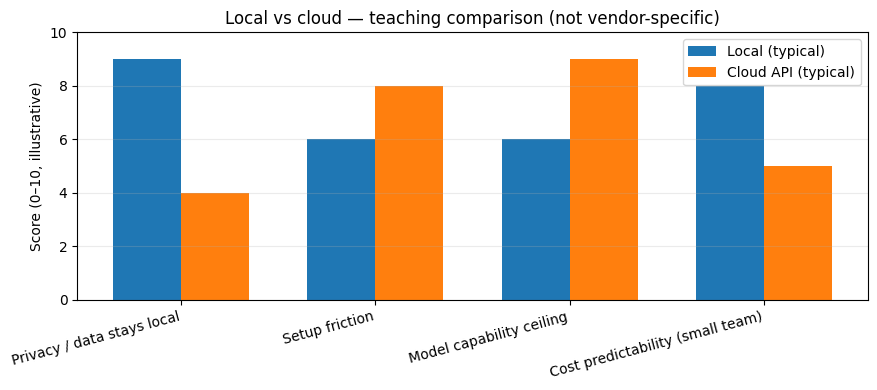

In [68]:
# Step 8 — Visual comparison (synthetic scores; no API key required)
# Uncomment once if matplotlib is missing:
# %pip install -q matplotlib
"""Higher = better for that criterion (subjective teaching defaults)."""

labels = ["Privacy / data stays local", "Setup friction", "Model capability ceiling", "Cost predictability (small team)"]
local_scores = [9, 6, 6, 8]
cloud_scores = [4, 8, 9, 5]

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is None:
    print("Install matplotlib for charts:  %pip install -q matplotlib\n")
    w = 40
    for i, lab in enumerate(labels):
        print(lab)
        la = int(local_scores[i] * w / 10)
        ca = int(cloud_scores[i] * w / 10)
        print("  local ", "#" * la, f" {local_scores[i]}/10")
        print("  cloud ", "#" * ca, f" {cloud_scores[i]}/10")
        print()
else:
    x = range(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar([i - width / 2 for i in x], local_scores, width, label="Local (typical)")
    ax.bar([i + width / 2 for i in x], cloud_scores, width, label="Cloud API (typical)")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylim(0, 10)
    ax.set_ylabel("Score (0–10, illustrative)")
    ax.set_title("Local vs cloud — teaching comparison (not vendor-specific)")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


In [69]:
def cloud_chat_demo() -> None:
    """Minimal OpenAI-compatible chat completion (optional)."""
    try:
        from pathlib import Path

        from dotenv import load_dotenv

        for env_dir in (Path.cwd(), Path.cwd().parent):
            env_path = env_dir / ".env"
            if env_path.is_file():
                load_dotenv(env_path)
                break
    except Exception:
        pass

    api_key = (os.environ.get("OPENAI_API_KEY") or "").strip()
    if not api_key:
        print(
            "Skip: set environment variable OPENAI_API_KEY to run the cloud demo.\n"
            "This notebook does not require cloud access for the main exercises."
        )
        return

    base_url = (
        os.environ.get("OPENAI_BASE_URL") or "https://api.openai.com/v1"
    ).rstrip("/")
    model = (os.environ.get("OPENAI_MODEL") or "gpt-4o-mini").strip()

    system_prompt = "You help engineers write clear, cautious summaries."
    user_prompt = (
        "In 80 words, explain when cloud LLMs may be preferable to local LLMs "
        "for workplace tasks, mentioning privacy and cost."
    )

    model_l = model.lower()
    reasoning_model = model_l.startswith(("o1", "o3"))
    if reasoning_model:
        # o-series models reject system role and temperature.
        messages = [
            {
                "role": "user",
                "content": f"{system_prompt}\n\n{user_prompt}",
            }
        ]
    else:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]

    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    body: Dict[str, Any] = {"model": model, "messages": messages}
    if not reasoning_model:
        body["temperature"] = 0.2

    url = f"{base_url}/chat/completions"
    r = requests.post(url, headers=headers, json=body, timeout=120)
    if not r.ok:
        detail = r.text.strip()
        try:
            err = r.json().get("error", {})
            detail = err.get("message") or detail
        except Exception:
            pass
        print(
            f"Cloud demo failed ({r.status_code} {r.reason}).\n"
            f"Model: {model!r} · URL: {url}\n"
            f"API message: {detail}\n\n"
            "Tips: verify OPENAI_API_KEY, use OPENAI_MODEL=gpt-4o-mini for this demo, "
            "and set OPENAI_BASE_URL=https://api.openai.com/v1 unless you use a proxy."
        )
        return

    data = r.json()
    text = data["choices"][0]["message"]["content"]
    display_llm_result(
        "Step 8 · Cloud API · Sample reply",
        text,
        subtitle=f"OpenAI-compatible · model {model}",
        explain="Cloud response—remember data left your runtime; review privacy policy.",
        show_reading_guide=False,
    )


cloud_chat_demo()

Cloud demo failed (400 Bad Request).
Model: 'gpt-4o-mini #gemini-2.0-flash' · URL: https://api.openai.com/v1/chat/completions
API message: invalid model ID

Tips: verify OPENAI_API_KEY, use OPENAI_MODEL=gpt-4o-mini for this demo, and set OPENAI_BASE_URL=https://api.openai.com/v1 unless you use a proxy.


### Cloud illustration — same task, two worlds

| Aspect | Local (`llama_cpp` / Ollama / transformers / LM Studio) | Cloud API |
|--------|---------------------|-----------|
| Data residency | Stays on PC / your server if configured | Leaves device unless enterprise controls apply |
| Setup | Install weights + runtime | API key + billing |
| Best for | Sensitive drafts, offline yards, iteration | Cutting-edge models, low local hardware |

Many teams use **local** for drafts and **cloud** for hardest reasoning—policy permitting.


## Step 9 — Local vs cloud: quick decision guide

**Prefer local** when:

- Documents are confidential or export-controlled.
- Network is unreliable (shipyard, field site).
- You want predictable offline demos.

**Consider cloud** when:

- You need top-tier multilingual or long-context performance.
- IT already approved a vendor and data-processing agreement.
- Local hardware cannot run the quality level you need.

**Hybrid workflow (common):** summarize or anonymize locally → optional cloud for polish (only if allowed).

In [70]:
# Step 9 — Interactive decision helper (edit sliders 1–5; no LLM call)
"""1 = low / disagree, 5 = high / agree — tune to your project."""

scores = {
    "data_sensitivity": 4,  # confidential / export-controlled content?
    "offline_need": 3,  # must work without internet?
    "local_hardware": 2,  # can this PC/server run a good enough model?
    "need_best_model": 3,  # need frontier reasoning / multilingual?
    "vendor_approved": 2,  # IT + legal approved cloud vendor + DPA?
}

w_local = (
    scores["data_sensitivity"] * 1.2
    + scores["offline_need"] * 1.1
    + scores["local_hardware"] * 0.9
    - scores["need_best_model"] * 0.7
)
w_cloud = (
    scores["need_best_model"] * 1.3
    + scores["vendor_approved"] * 1.4
    - scores["data_sensitivity"] * 1.1
    - scores["offline_need"] * 0.9
)

print("Weighted tilt (higher = stronger signal):\n  local_support", round(w_local, 2), "\n  cloud_support", round(w_cloud, 2))

if w_local - w_cloud >= 0.8:
    rec = "LEAN LOCAL: prioritize on-device / private server LLMs; use cloud only for anonymized or approved workloads."
elif w_cloud - w_local >= 0.8:
    rec = "LEAN CLOUD: policy and connectivity allow; still scrub sensitive fields before sending."
else:
    rec = "HYBRID: draft/redact locally; optional cloud for polish or hardest tasks if approved."

print("\nRecommendation:\n ", rec)

print("\n--- Your inputs ---")
for k, v in scores.items():
    print(f"  {k}: {v}/5")


Weighted tilt (higher = stronger signal):
  local_support 7.8 
  cloud_support -0.4

Recommendation:
  LEAN LOCAL: prioritize on-device / private server LLMs; use cloud only for anonymized or approved workloads.

--- Your inputs ---
  data_sensitivity: 4/5
  offline_need: 3/5
  local_hardware: 2/5
  need_best_model: 3/5
  vendor_approved: 2/5


## Step 10 — Limitations, privacy, and safe use

- **Hallucinations:** The model can sound confident while wrong—verify critical values.
- **PII / secrets:** Do not paste passwords, full passport numbers, or unreleased pricing without policy clearance.
- **IP:** Customer drawings and class correspondence may be restricted—follow your company rules.
- **Safety-critical systems:** LLM output is **not** a substitute for engineering sign-off.
- **Bias & tone:** Review externally facing text before sending.

**Closing suggestion:** Keep a personal library of 5–10 prompt templates that work for *your* recurring tasks—refine them monthly.

In [71]:
# Step 10 — Printable pre-flight checklist (no LLM; copy to procedures if useful)
from datetime import date

checklist = f"""
## LLM use — pre-flight checklist ({date.today().isoformat()})

- [ ] **Data class:** Is this document OK to leave the device under company policy?
- [ ] **PII removed:** Names, IDs, exact pricing, hull numbers redacted unless allowed.
- [ ] **Safety / compliance:** No single-source LLM output for load-out, stability, or class submissions without review.
- [ ] **Verification plan:** Who signs off if numbers (torque, pressure, dates) matter?
- [ ] **Fallback:** What do we do if the model returns nonsense or DEMO MODE?
- [ ] **Retention:** Are we allowed to store this prompt/output in tickets/email archives?

**One-line purpose of this session:** ________________________________________________
"""

print(checklist)

# Optional LLM critique — set True after Step 4 + replace snippet below
RUN_OPTIONAL_LLM_CRITIQUE = False

SANITIZED_POLICY_SNIPPET = """
(Replace with a short anonymized policy paragraph you are allowed to process.)
""".strip()

if RUN_OPTIONAL_LLM_CRITIQUE:
    _fn = globals().get("call_llm")
    if _fn is None:
        print("Run Step 4 first (defines call_llm).")
    elif "Replace with" in SANITIZED_POLICY_SNIPPET:
        print("Edit SANITIZED_POLICY_SNIPPET before enabling RUN_OPTIONAL_LLM_CRITIQUE.")
    else:
        critique = _fn(
            "List 5 concrete risks if teams rely on LLMs for this kind of content without governance. Bullet points only.\n\nTEXT:\n"
            + SANITIZED_POLICY_SNIPPET,
            system="Do not invent company names or laws.",
            temperature=0.1,
        )
        print("\n--- Optional model critique ---\n")
        print(critique)



## LLM use — pre-flight checklist (2026-06-18)

- [ ] **Data class:** Is this document OK to leave the device under company policy?
- [ ] **PII removed:** Names, IDs, exact pricing, hull numbers redacted unless allowed.
- [ ] **Safety / compliance:** No single-source LLM output for load-out, stability, or class submissions without review.
- [ ] **Verification plan:** Who signs off if numbers (torque, pressure, dates) matter?
- [ ] **Fallback:** What do we do if the model returns nonsense or DEMO MODE?
- [ ] **Retention:** Are we allowed to store this prompt/output in tickets/email archives?

**One-line purpose of this session:** ________________________________________________



## Appendix A — Running **Ollama** on Google Colab (optional)

Colab runtimes are **Linux x86_64**, so you can install the official **Ollama** Linux build **inside the same VM** and call `http://127.0.0.1:11434`. Treat this as **experimental**: sessions disconnect, disks reset, and free-tier **RAM/GPU** are limited.

**1. Install** (once per new runtime):

```bash
curl -fsSL https://ollama.com/install.sh | sh
```

**2. Start the daemon in the background** (otherwise commands hang):

```bash
nohup ollama serve > /tmp/ollama.log 2>&1 &
sleep 3
```

**3. Pull a model** (free Colab RAM is tight — prefer smaller pulls when unsure):

```bash
ollama pull llama3.2
```

(Fallback if **OOM** / timeout: `ollama pull tinyllama` and set `"model": "tinyllama"` in the Python example below.)


**4. Call from Python** (same notebook):

```python
import requests
r = requests.post(
    "http://127.0.0.1:11434/api/generate",
    json={"model": "llama3.2", "prompt": "Say hello in one sentence.", "stream": False},
    timeout=120,
)
print(r.json().get("response", ""))
```

**Limits:** ephemeral VM, possible **OOM** with large models, GPU behaviour varies by runtime. The main notebook path uses **`llama-cpp-python` + GGUF** (Step 0b / Step 4), which does not need the Ollama daemon. The snippet above is for **`LLM_BACKEND=ollama`** only.

**Alternative on Colab:** use the default **`LLM_BACKEND=llama_cpp`** (Step 0–4), or set **`LLM_BACKEND=transformers`** if `llama-cpp-python` wheels fail to install.


## Appendix B — Instructor notes (optional)

- **Time box:** 90–150 minutes: Steps 1–4c (pick scenarios) + **Step 5–7**; Step 8 chart + optional cloud API as demo/homework; Steps 9–10 as discussion + quick forms.
- **Models:** **Default path:** **`llama-cpp-python`** + **GGUF** from Hugging Face (Step 0b). Optional: **`LLM_BACKEND=ollama`**, or **`TRANSFORMERS_MODEL_ID`** (e.g. TinyLlama or gated Llama + `HF_TOKEN`).
- **GPU labs:** CUDA + `device_map=auto` helps larger models; CPU-only classes should keep TinyLlama or a small instruct model.
- **Assessment:** Ask learners to bring one real (anonymized) paragraph and improve it with two prompt iterations.
